# Projeto 1 - Insper AI 

In [1]:
import pandas as pd
df = pd.read_csv("cars.csv", low_memory=False)
df.head(10)

,id,ref_code,maker,first_reg,listed_yr,listed_mo,odo,disp,gearbox,fuel,...,doors,seats,paint,power_bhp,econ_mpg,length_mm,annual_tax,entry_price,pct_of_list,price
0,A6796895,M1288,Bentley,2000.0,2018,4,60000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,145000.0,0.1483,21500
1,A6544792,M1288,Bentley,2002.0,2018,6,44000,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,450.0,13.7 mpg,5390.0,315,149000.0,0.1930,28750
2,A9945056,M1288,Bentley,2002.0,2017,11,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,400.0,14.7 mpg,5390.0,315,149000.0,0.2013,29999
3,A7702534,M1288,Bentley,2003.0,2018,4,14000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,NaN,NaN,5390.0,NaN,151500.0,0.2307,34948
4,A1024660,M1288,Bentley,2003.0,2017,11,61652,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,NaN,NaN,5390.0,NaN,151500.0,0.1753,26555
5,A6714845,M1288,Bentley,2002.0,2017,12,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,450.0,13.7 mpg,5390.0,315,149000.0,0.1674,24950
6,A5108990,M1288,Bentley,2002.0,2018,8,67000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,450.0,13.7 mpg,5390.0,NaN,149000.0,0.2013,29995
7,A5499375,M1288,Bentley,2003.0,2018,4,99200,6.8L,Automatic,Petrol,...,4.0,5.0,Black,NaN,NaN,5390.0,NaN,151500.0,0.1482,22450
8,A7439592,M1288,Bentley,2003.0,2018,2,27541,6.8L,Automatic,Petrol,...,4.0,4.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1782,26990
9,A4767271,M1288,Bentley,2003.0,2017,11,38000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1980,29995


## Parte 1 — Análise exploratória (superficial)



Visão geral da base: tamanho, tipos, valores faltantes, colunas que precisam de limpeza e distribuição dos dois alvos (`price` e `gearbox`).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)
df.info()

(170150, 21)
<class 'pandas.DataFrame'>
RangeIndex: 170150 entries, 0 to 170149
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           170150 non-null  str    
 1   ref_code     170150 non-null  str    
 2   maker        170150 non-null  str    
 3   first_reg    170145 non-null  float64
 4   listed_yr    170150 non-null  int64  
 5   listed_mo    170150 non-null  int64  
 6   odo          169472 non-null  str    
 7   disp         169011 non-null  str    
 8   gearbox      170033 non-null  str    
 9   fuel         169800 non-null  str    
 10  body         169440 non-null  str    
 11  doors        166646 non-null  float64
 12  seats        165319 non-null  float64
 13  paint        150865 non-null  str    
 14  power_bhp    148271 non-null  float64
 15  econ_mpg     141809 non-null  str    
 16  length_mm    152138 non-null  float64
 17  annual_tax   139864 non-null  str    
 18  entry_price  144352 no

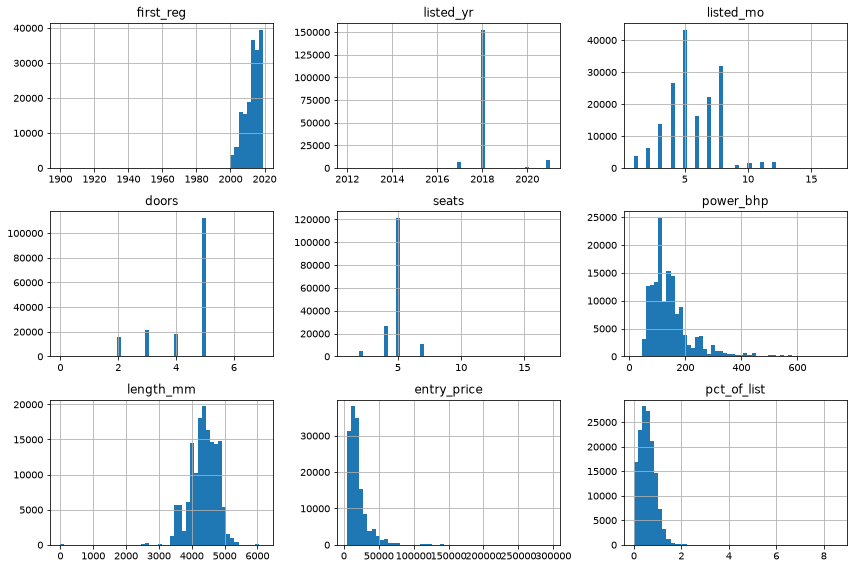

In [3]:
df.hist(bins=50, figsize=(12, 8)) 
plt.tight_layout() 
plt.show()

### Valores faltantes

In [3]:
faltantes = df.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(1).to_frame("% faltante")

,% faltante
annual_tax,17.8
econ_mpg,16.7
pct_of_list,15.4
entry_price,15.2
power_bhp,12.9
paint,11.3
length_mm,10.6
seats,2.8
doors,2.1
disp,0.7


### Colunas numéricas guardadas como texto


`price`, `odo`, `disp`, `econ_mpg` e `annual_tax` vêm como texto (sufixos como `L`, `mpg`, `mile(s)`, `*`, ou o valor `"Uknown"` em `price`). Abaixo, os valores que não viram número diretamente.

In [4]:
for col in ["price", "odo", "disp", "econ_mpg", "annual_tax"]:
    s = df[col].dropna().astype(str)
    nao_num = s[pd.to_numeric(s, errors="coerce").isna()]
    print(f"{col}: {len(nao_num)} valores não numéricos | exemplos: {nao_num.value_counts().head(5).to_dict()}")

price: 914 valores não numéricos | exemplos: {'Uknown': 914}
odo: 207 valores não numéricos | exemplos: {'1 mile': 207}
disp: 169011 valores não numéricos | exemplos: {'2.0L': 40908, '1.6L': 26332, '3.0L': 15174, '1.2L': 13350, '1.4L': 12784}
econ_mpg: 141809 valores não numéricos | exemplos: {'47.1 mpg': 5511, '62.8 mpg': 5495, '55.4 mpg': 5258, '47.9 mpg': 5072, '54.3 mpg': 4511}
annual_tax: 21719 valores não numéricos | exemplos: {' 140*': 20063, ' 130*': 1126, '*': 401, ' 0*': 129}


In [5]:
# Conversão rápida só para a exploração (a limpeza definitiva fica para o pipeline)
eda = df.copy()
eda["price"] = pd.to_numeric(eda["price"], errors="coerce")
eda["odo"] = pd.to_numeric(eda["odo"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
eda["disp"] = pd.to_numeric(eda["disp"].str.rstrip("L"), errors="coerce")
eda["econ_mpg"] = pd.to_numeric(eda["econ_mpg"].str.replace("mpg", ""), errors="coerce")
eda["annual_tax"] = pd.to_numeric(eda["annual_tax"].str.replace("*", "", regex=False), errors="coerce")
eda["idade"] = eda["listed_yr"] - eda["first_reg"]

eda.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
first_reg,170145.0,2012.69,4.50,1900.00,2010.00,2014.00,2016.00,2019.00
listed_yr,170150.0,2018.12,0.74,2012.00,2018.00,2018.00,2018.00,2021.00
listed_mo,170150.0,5.61,2.08,1.00,4.00,5.00,7.00,17.00
odo,169472.0,48182.55,42992.03,0.00,14354.00,39117.00,74600.00,6363342.00
disp,169011.0,11.56,145.66,0.30,1.40,1.80,2.00,6900.00
doors,166646.0,4.36,1.02,0.00,4.00,5.00,5.00,7.00
seats,165319.0,4.89,0.86,1.00,5.00,5.00,5.00,17.00
power_bhp,148271.0,148.19,80.85,17.00,99.00,128.00,171.00,740.00
econ_mpg,141809.0,51.26,13.42,9.80,42.20,50.40,60.10,200.00
length_mm,152138.0,4366.60,420.18,0.00,4083.00,4387.00,4672.00,6165.00


### Variáveis categóricas

In [6]:
cat_cols = ["maker", "ref_code", "gearbox", "fuel", "body", "paint"]
eda[cat_cols].nunique().to_frame("categorias distintas")

,categorias distintas
maker,88
ref_code,513
gearbox,3
fuel,13
body,18
paint,22


In [7]:
for col in ["gearbox", "fuel", "body"]:
    print(eda[col].value_counts(dropna=False), "\n")

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64 

fuel
Diesel                             83053
Petrol                             81148
Hybrid  Petrol/Electric             3767
Electric                             703
Hybrid  Petrol/Electric Plug-in      462
NaN                                  350
Petrol Hybrid                        298
Petrol Plug-in Hybrid                185
Hybrid  Diesel/Electric               81
Diesel Hybrid                         34
Hybrid  Diesel/Electric Plug-in       34
Bi Fuel                               25
Petrol Ethanol                         8
Diesel Plug-in Hybrid                  2
Name: count, dtype: int64 

body
Hatchback          67035
SUV                39354
Saloon             14542
MPV                13775
Estate             11533
Coupe              10901
Convertible         8846
Pickup              2455
NaN                  710
Combi Van            450
Pa

In [8]:
eda["maker"].value_counts().head(15)

maker
Ford             21045
Audi             14296
Vauxhall         13577
BMW              12080
Volkswagen       11917
Toyota            8013
Peugeot           7112
Nissan            6098
Mazda             5463
Jaguar            5137
Mercedes-Benz     5015
Kia               4999
Renault           4984
SKODA             4568
Volvo             4519
Name: count, dtype: int64

### Alvo 1: `price`

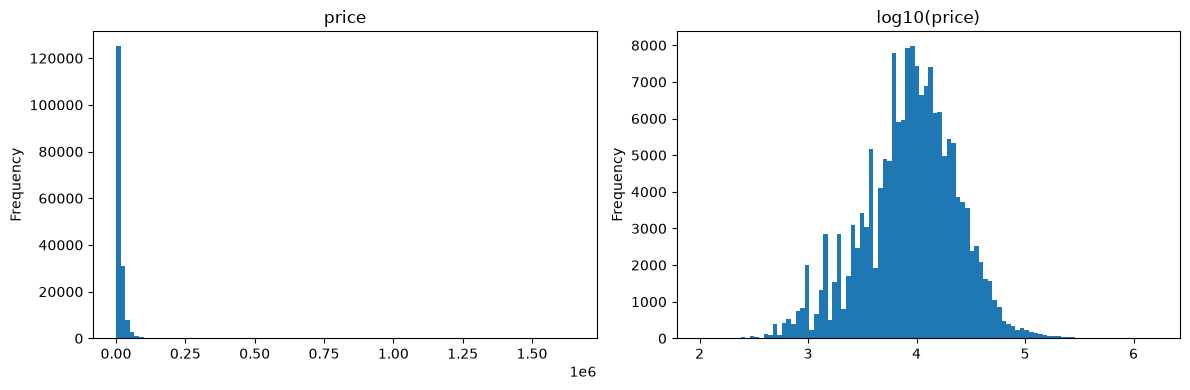

count     169236.0
mean       14104.0
std        20662.0
min          100.0
1%           695.0
25%         4990.0
50%         9395.0
75%        16995.0
99%        79950.0
max      1650000.0
Name: price, dtype: float64

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda["price"].plot.hist(bins=100, ax=axes[0], title="price")
np.log10(eda["price"]).plot.hist(bins=100, ax=axes[1], title="log10(price)")
plt.tight_layout()
plt.show()

eda["price"].describe(percentiles=[.01, .25, .5, .75, .99]).round(0)

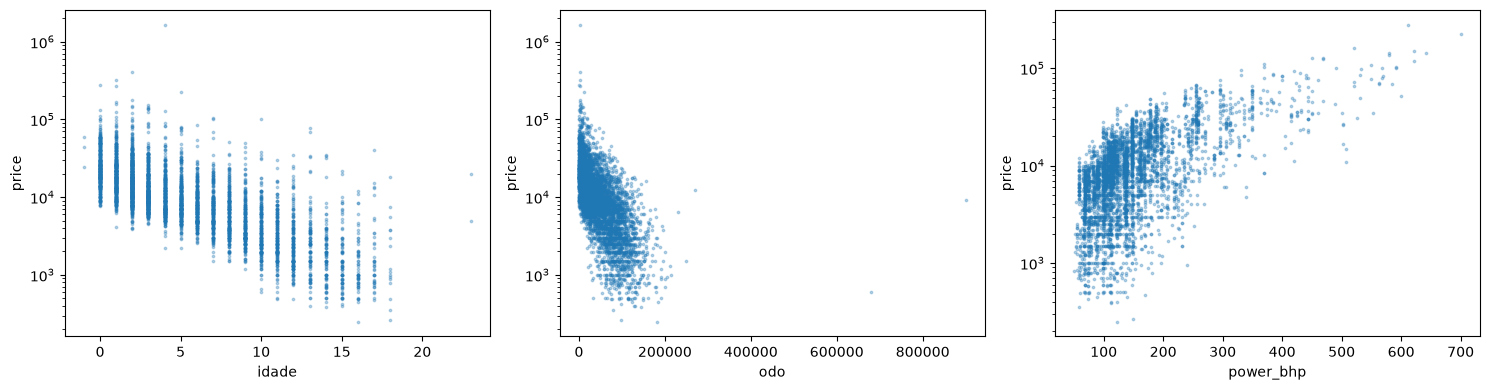

idade         -0.343933
odo           -0.328904
econ_mpg      -0.166858
doors         -0.152275
seats         -0.125222
listed_mo     -0.038701
disp           0.018878
listed_yr      0.101949
annual_tax     0.185979
length_mm      0.333384
first_reg      0.346075
pct_of_list    0.599356
power_bhp      0.695483
entry_price    0.796869
Name: price, dtype: float64

In [10]:
# Relação do preço com algumas numéricas (amostra para o gráfico ficar leve)
amostra = eda.sample(5000, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["idade", "odo", "power_bhp"]):
    ax.scatter(amostra[col], amostra["price"], s=3, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("price")
plt.tight_layout()
plt.show()

eda.select_dtypes("number").corr()["price"].drop("price").sort_values()

### Alvo 2: `gearbox`

In [11]:
print(eda["gearbox"].value_counts(normalize=True).round(3))

# Proporção de automáticos por algumas categorias
for col in ["fuel", "body"]:
    tab = (eda.assign(auto=eda["gearbox"].eq("Automatic"))
              .groupby(col)["auto"].agg(["mean", "size"])
              .query("size >= 100").sort_values("mean", ascending=False))
    print(tab.round(3), "\n")

gearbox
Manual            0.640
Automatic         0.359
Semi-Automatic    0.001
Name: proportion, dtype: float64
                                  mean   size
fuel                                         
Hybrid  Petrol/Electric Plug-in  1.000    462
Petrol Plug-in Hybrid            1.000    185
Electric                         0.994    703
Petrol Hybrid                    0.990    298
Hybrid  Petrol/Electric          0.967   3767
Diesel                           0.411  83053
Petrol                           0.262  81148 

              mean   size
body                     
Panel Van    0.769    221
Saloon       0.640  14542
Coupe        0.586  10901
SUV          0.501  39354
Estate       0.416  11533
Convertible  0.395   8846
Pickup       0.349   2455
MPV          0.293  13775
Combi Van    0.209    450
Hatchback    0.177  67035 



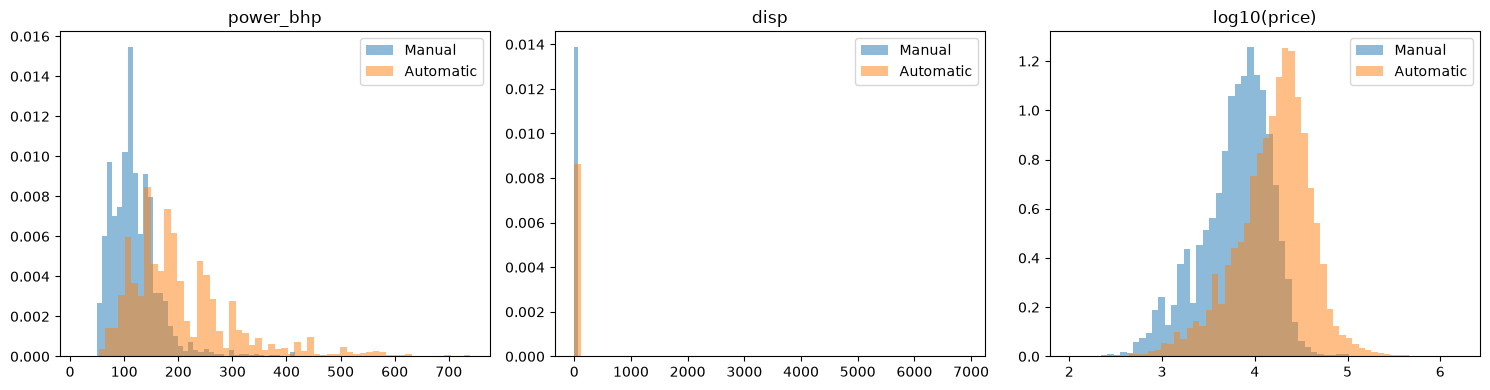

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["power_bhp", "disp", "price"]):
    for g in ["Manual", "Automatic"]:
        vals = eda.loc[eda["gearbox"] == g, col].dropna()
        if col == "price":
            vals = np.log10(vals)
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=g)
    ax.set_title(col if col != "price" else "log10(price)")
    ax.legend()
plt.tight_layout()
plt.show()

### Primeiras observações


- **170 mil anúncios, 21 colunas.** Várias colunas numéricas estão como texto (`price`, `odo`, `disp`, `econ_mpg`, `annual_tax`) e precisam de limpeza.
- **`price` tem 914 valores `"Uknown"`** — essas linhas não servem para treinar o modelo de preço. A distribuição é bem assimétrica; `log(price)` fica muito mais comportada.
- **`pct_of_list` = `price / entry_price`**: usa o próprio alvo, então é **vazamento** e não pode entrar no modelo de preço (nem estará disponível num anúncio novo).
- **`gearbox`**: ~64% Manual, ~36% Automatic, e só 110 `Semi-Automatic` (decidir se descarta ou agrupa). Potência, cilindrada e preço separam bem as classes.
- **Faltantes** de até ~18% em `annual_tax`, `econ_mpg`, `entry_price`, `power_bhp`, `length_mm` e `paint`.
- **Anomalias**: `listed_mo` tem um valor 17; `body` tem 5 linhas `"Manual"`; `fuel` tem variações de escrita do mesmo tipo (ex.: `Hybrid  Petrol/Electric` vs `Petrol Hybrid`); `odo` tem valores como `"1 mile"`.
- **Alta cardinalidade**: `ref_code` (513) e `maker` (88) exigem cuidado na codificação, especialmente porque o conjunto de avaliação tem composição diferente.

## Parte 2 — Limpeza da base de dados


Cada problema segue o ciclo **o que vimos → teste → decisão**. No final, as decisões vão para uma função, `limpar()`, aplicada também ao arquivo de avaliação. Ela **não aprende nada dos dados**, **não apaga linhas** (valores impossíveis viram `NaN`) e **não quebra se faltar coluna** (a avaliação não terá `price` nem `gearbox`).

In [14]:
import re

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)

(170150, 21)


### Problema 1 — `pct_of_list` 


**O que vimos:** o dicionário de dados define `pct_of_list` como `price / entry_price`. Se isso for verdade, essa coluna **contém o alvo** do Modelo 1: sabendo `pct_of_list` e `entry_price`, o preço sai por uma multiplicação.

**Hipótese a testar:** `pct_of_list` é exatamente `price / entry_price` em todas as linhas.

In [15]:
# O dicionário diz que pct_of_list = price / entry_price. Vamos conferir.
preco_num = pd.to_numeric(df["price"], errors="coerce")
razao_recalculada = preco_num / df["entry_price"]

tem_os_dois = df["pct_of_list"].notna() & razao_recalculada.notna()
bate = (razao_recalculada[tem_os_dois] - df.loc[tem_os_dois, "pct_of_list"]).abs() < 0.001

print("linhas com pct_of_list preenchido:", tem_os_dois.sum())
print("% em que pct_of_list = price / entry_price:", round(bate.mean() * 100, 2))
print("linhas com price desconhecido mas pct_of_list preenchido:",
      (preco_num.isna() & df["pct_of_list"].notna()).sum())

linhas com pct_of_list preenchido: 143907
% em que pct_of_list = price / entry_price: 100.0
linhas com price desconhecido mas pct_of_list preenchido: 0


**Resultado:** nas 143.907 linhas preenchidas, `pct_of_list` = `price / entry_price` em **100%** dos casos, e ela fica vazia quando o preço é desconhecido.

**Decisão: remover `pct_of_list`.** É vazamento do alvo no Modelo 1 e traria o preço "escondido" para o Modelo 2.

### Problema 2 — `price` como texto e preços extremos


**O que vimos:** `price` veio como texto, porque algumas linhas não têm número. A distribuição também é muito assimétrica: vai de £100 a £1,65 milhão.

**Perguntas:**
1. Quais valores não são número?
2. Os preços extremos são erros de digitação ou carros reais?

In [16]:
# Quais valores de price não são números?
nao_numericos = df.loc[preco_num.isna(), "price"]
print(nao_numericos.value_counts(dropna=False))

price
Uknown    914
Name: count, dtype: int64


In [17]:
# Os anúncios mais baratos e mais caros fazem sentido?
contexto = ["maker", "first_reg", "listed_yr", "odo", "entry_price", "price"]
aux = df.assign(price_num=preco_num).sort_values("price_num")

print("10 mais baratos:")
print(aux[contexto].head(10))
print("\n10 mais caros:")
print(aux.dropna(subset=["price_num"])[contexto].tail(10))

10 mais baratos:
             maker  first_reg  listed_yr     odo  entry_price price
142922    Vauxhall     2004.0       2018  115000       9825.0   100
90257      Renault     2002.0       2018   78451       7370.0   100
21563         Ford     2003.0       2018   61545       6370.0   100
148123    Vauxhall     2011.0       2018   70000       8940.0   100
17031         Ford     2004.0       2018   89000       9830.0   125
22350         Ford     2004.0       2018  100000       6632.0   150
151680  Volkswagen     2001.0       2018  215000      10570.0   150
90932      Renault     2006.0       2018     NaN       7350.0   175
142816    Vauxhall     2001.0       2018  147000      10115.0   180
114005       Smart     2002.0       2018   72941       6170.0   180

10 mais caros:
             maker  first_reg  listed_yr    odo  entry_price    price
84688      Porsche     2018.0       2018     50      77891.0   549995
6040       Ferrari     2011.0       2018  18668          NaN   599995
6043     

**Resultado:** o único valor não numérico é `"Uknown"` (**914 linhas**). Os mais baratos (£100–£180) são carros populares de 2001–2006 com muita quilometragem; os mais caros são hipercarros reais (Bugatti, Pagani, Ferrari).

**Decisões:** `"Uknown"` vira `NaN` (fora do treino do Modelo 1, mas útil no Modelo 2). **Os extremos são mantidos:** não dá para provar que são erro, são poucos (menos de 20 abaixo de £200), o modelo usa `log(price)`, e a análise de erros mostra onde ele erra mais.

### Problema 3 — Categorias de `gearbox`


**O que vimos:** além de `Automatic` e `Manual`, existe `Semi-Automatic`, e há linhas sem câmbio. O enunciado pede só duas classes para o modelo 2.

**Pergunta:** quem são os semiautomáticos? Eles se parecem mais com automáticos ou com manuais?

In [13]:
print(df["gearbox"].value_counts(dropna=False))
print("\nQuem são os Semi-Automatic:")
print(df.loc[df["gearbox"] == "Semi-Automatic", "maker"].value_counts().head(8))

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64

Quem são os Semi-Automatic:
maker
Porsche        33
Lamborghini    14
Bentley         9
Ford            9
Hyundai         8
Volkswagen      8
Ferrari         5
SKODA           5
Name: count, dtype: int64


**Resultado:** 108.838 manuais, 61.085 automáticos, **110 semiautomáticos** (Porsche, Lamborghini, Bentley, Ferrari, VW: câmbios de dupla embreagem) e **117 sem câmbio**.

**Decisões:** `Semi-Automatic` → `Automatic` (não têm pedal de embreagem; 0,06% da base). Alvo binário `auto` (1 = Automatic). As 117 linhas sem câmbio ficam fora do treino do Modelo 2, mas recebem previsão normalmente.

### Problema 4 — Colunas numéricas guardadas como texto


**O que vimos:** `odo`, `disp`, `econ_mpg` e `annual_tax` vieram como texto por causa de sufixos (`L`, `mpg`, `mile`, `*`). Para ver só os formatos, trocamos todo dígito por `9`.

In [19]:
# Quais "formatos" aparecem em cada coluna? Trocamos todo dígito por 9 para ver só o padrão.
for col in ["odo", "disp", "econ_mpg", "annual_tax"]:
    formatos = df[col].dropna().astype(str).str.replace(r"\d", "9", regex=True)
    print(f"{col}: {formatos.value_counts().head(6).to_dict()}")

odo: {'99999': 118529, '9999': 23751, '999999': 19910, '99': 3694, '999': 2456, '9': 923}
disp: {'9.9L': 165970, '9.99L': 2198, '9999.9L': 838, '999.9L': 5}
econ_mpg: {'99.9 mpg': 141591, '999.9 mpg': 217, '9.9 mpg': 1}
annual_tax: {' 999': 81575, ' 99': 27659, ' 999*': 21189, ' 9': 8911, '*': 401, ' 9*': 129}


**Resultado:** os formatos são sempre "número + sufixo" (`9.9L`, `99.9 mpg`, ` 999*`, `9 mile`).

**Decisão:** uma regra para todas as colunas: **extrair o primeiro número do texto**; o que não tem número vira `NaN`.

In [20]:
def _para_numero(serie):
    """Extrai o primeiro número de um texto ('6.8L' -> 6.8, ' 140*' -> 140, '1 mile' -> 1)."""
    texto = serie.astype("string")
    numero = pd.to_numeric(texto.str.extract(r"(-?\d+\.?\d*)", expand=False), errors="coerce")
    return numero.astype("float64")


# Teste com um exemplo de cada formato
exemplos = pd.Series(["6.8L", "47.1 mpg", " 140*", " 30", "*", "1 mile", "60000", "Uknown", np.nan])
pd.DataFrame({"original": exemplos, "convertido": _para_numero(exemplos)})

,original,convertido
0,6.8L,6.8
1,47.1 mpg,47.1
2,140*,140.0
3,30,30.0
4,*,NaN
5,1 mile,1.0
6,60000,60000.0
7,Uknown,NaN
8,NaN,NaN


Todos os formatos foram convertidos corretamente. Também padronizamos os textos (espaços nas pontas e duplicados, como em `"Hybrid  Petrol/Electric"`), para o mesmo valor não virar duas categorias.

In [21]:
def _limpar_texto(serie):
    """Tira espaços nas pontas e espaços repetidos ('Hybrid  Petrol' -> 'Hybrid Petrol').
    Funciona mesmo se a coluna vier vazia ou numérica no arquivo de avaliação."""
    return serie.map(lambda x: re.sub(r"\s+", " ", str(x)).strip() if pd.notna(x) else np.nan).astype("object")


exemplos = pd.Series(["Hybrid  Petrol/Electric", " 140*", "Petrol", np.nan])
pd.DataFrame({"original": exemplos.map(repr), "limpo": _limpar_texto(exemplos).map(repr)})

,original,limpo
0,'Hybrid Petrol/Electric','Hybrid Petrol/Electric'
1,' 140*','140*'
2,'Petrol','Petrol'
3,nan,nan


### Problema 5 — Cilindrada (`disp`)



**O que vimos:** depois de converter para número, vamos olhar a distribuição. Cilindradas de carros de passeio ficam tipicamente entre 0,6 e 8 litros.

In [22]:

disp_num = _para_numero(df["disp"])
print(disp_num.describe().round(2))
print("\nvalores >= 100:", (disp_num >= 100).sum())
print(df.loc[disp_num >= 100, "disp"].value_counts().head(8))

count    169011.00
mean         11.56
std         145.66
min           0.30
25%           1.40
50%           1.80
75%           2.00
max        6900.00
Name: disp, dtype: float64

valores >= 100: 843
disp
2000.0L    215
1600.0L    140
3000.0L     85
1400.0L     69
1000.0L     58
1200.0L     53
2200.0L     32
1500.0L     30
Name: count, dtype: int64


**Resultado:** mediana de 1,8 L, mas **843 linhas têm valor ≥ 100** (`2000.0L`, `1600.0L`, `3000.0L`). **Hipótese:** estão em cc. **Teste:** se for verdade, cada valor deve ser ~1000× a cilindrada típica do mesmo `ref_code`.

In [23]:
# Hipótese: os valores >= 100 estão em cc. Se for verdade, eles devem ser ~1000x a cilindrada
# típica do mesmo modelo de carro (ref_code), calculada só com as linhas "normais".
normais = disp_num < 100
mediana_por_ref = disp_num[normais].groupby(df.loc[normais, "ref_code"]).median()

suspeitos = disp_num >= 100
comparacao = pd.DataFrame({
    "disp_lido": disp_num[suspeitos],
    "mediana_do_ref_code": df.loc[suspeitos, "ref_code"].map(mediana_por_ref),
})
comparacao["razao"] = comparacao["disp_lido"] / comparacao["mediana_do_ref_code"]
print(comparacao["razao"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

count     843.0
mean     1013.2
std       147.7
min       600.0
10%       875.0
25%      1000.0
50%      1000.0
75%      1000.0
90%      1185.3
max      2200.0
Name: razao, dtype: float64


**Resultado:** a razão tem **mediana exatamente 1000** (80% dos casos entre 875 e 1185). **Hipótese confirmada. Decisão:** valores ≥ 100 são divididos por 1000.

In [24]:
# Depois de dividir por 1000, quais são os menores valores? E os elétricos?
disp_corrigido = disp_num.where(disp_num < 100, disp_num / 1000)
print("menores cilindradas:")
print(df.assign(disp_corrigido=disp_corrigido).nsmallest(5, "disp_corrigido")[["maker", "ref_code", "disp", "fuel"]])
print("\ncilindrada dos elétricos:")
print(df.loc[df["fuel"] == "Electric", "disp"].value_counts(dropna=False))

menores cilindradas:
                maker ref_code  disp    fuel
66439   Mercedes-Benz    M1074  0.3L  Petrol
113727          Smart    M1689  0.6L  Petrol
113737          Smart    M1689  0.6L  Petrol
113756          Smart    M1689  0.6L  Petrol
113761          Smart    M1689  0.6L  Petrol

cilindrada dos elétricos:
disp
NaN     691
2.0L      5
1.0L      4
4.0L      2
6.6L      1
Name: count, dtype: int64


**Resultado:** o menor valor (0,3 L, um Mercedes) é impossível; o menor motor real é o do Smart (0,6 L). Dos 703 elétricos, **691 não têm cilindrada**, o que é correto.

**Decisões:** cilindradas fora de **0,5 a 9 L** viram `NaN`; **elétrico sem cilindrada recebe 0** ("não tem motor" é informação, diferente de "não sabemos").

### Problema 6 — Quilometragem (`odo`)


**O que vimos:** a quilometragem (em milhas) tem valores muito altos e um formato `"1 mile"`.

**Pergunta:** a partir de que ponto a quilometragem deixa de ser plausível?

In [25]:
odo_num = _para_numero(df["odo"])
print(odo_num.describe(percentiles=[0.01, 0.5, 0.99, 0.999]).round(0))
print("\nAnúncios com mais de 300 mil milhas:")
print(df.assign(odo_num=odo_num).query("odo_num > 300000")
        .sort_values("odo_num")[["maker", "first_reg", "body", "odo_num", "price"]])

count     169472.0
mean       48183.0
std        42992.0
min            0.0
1%            10.0
50%        39117.0
99%       159576.0
99.9%     210000.0
max      6363342.0
Name: odo, dtype: float64

Anúncios com mais de 300 mil milhas:
                             maker  first_reg         body    odo_num  price
68203                Mercedes-Benz     2009.0          MPV   304850.0   5200
17032                         Ford     2005.0    Hatchback   324000.0    999
44686                       Jaguar     2011.0       Saloon   328000.0   7995
94062                         SEAT     2010.0    Hatchback   328856.0   1985
57323   London Taxis International     2002.0          NaN   331337.0   1200
45985                          Kia     2007.0          MPV   345000.0    795
133511                      Toyota     2013.0          SUV   425000.0  13495
53791                   Land Rover     2014.0          SUV   478566.0  27995
22269                         Ford     2008.0    Hatchback   680421.0   

**Resultado:** 99% dos carros têm menos de 160 mil milhas. Até ~480 mil são veículos de uso intenso plausíveis (táxi, SUV); a partir de 680 mil (até 6,3 milhões) são carros baratos comuns, provavelmente com zeros a mais.

**Decisão:** acima de **500 mil milhas** vira `NaN` (9 anúncios). E o `"1 mile"`?

In [26]:
# "1 mile": são carros novos?
um_mile = df["odo"] == "1 mile"
print("anúncios com '1 mile':", um_mile.sum())
print("anos entre registro e anúncio:")
print((df.loc[um_mile, "listed_yr"] - df.loc[um_mile, "first_reg"]).value_counts())

anúncios com '1 mile': 207
anos entre registro e anúncio:
 0.0    177
 1.0     15
-1.0     12
 3.0      1
 2.0      1
-3.0      1
Name: count, dtype: int64


**Resultado:** dos 207 anúncios com `"1 mile"`, 177 foram anunciados **no mesmo ano** do registro. São carros zero, com a quilometragem de entrega.

**Decisão:** manter. É um valor verdadeiro, e o conversor já transforma `"1 mile"` em 1.

### Problema 7 — O asterisco em `annual_tax`


**O que vimos:** ~21 mil impostos com asterisco (`" 140*"`), e a nota do dicionário não veio no arquivo. **Hipótese:** marca o regime de imposto criado em abril de 2017 (taxa fixa de £140, £130 ou £0). Se for isso, deve aparecer só em carros de 2017 em diante e quase só com esses valores.

In [27]:
tax_txt = _limpar_texto(df["annual_tax"])
tem_asterisco = tax_txt.str.contains("*", regex=False)

print("valores com asterisco:")
print(tax_txt[tem_asterisco == True].value_counts())
print("\nRegistrado a partir de 2017 x tem asterisco:")
print(pd.crosstab(df["first_reg"] >= 2017, tem_asterisco, rownames=["first_reg >= 2017"], colnames=["asterisco"]))

valores com asterisco:
annual_tax
140*    20063
130*     1126
*         401
0*        129
Name: count, dtype: int64

Registrado a partir de 2017 x tem asterisco:
asterisco           False  True 
first_reg >= 2017               
False              113658    103
True                 4487  21616


**Resultado:** hipótese confirmada: com asterisco só aparecem `140*`, `130*`, `0*` e `*`, e **99,5%** desses anúncios são de carros registrados a partir de 2017.

**Decisão:** o asterisco vira a coluna `tax_novo_regime` (1 = regime novo); o valor numérico do imposto é mantido.

### Problema 8 — Ano de registro (`first_reg`)


**O que vimos:** existem anúncios em que o carro foi **registrado depois** do ano do anúncio, o que à primeira vista parece impossível. Também há um registro em 1900.

**Pergunta:** isso é erro de digitação, ou existe uma explicação real?

In [28]:
depois = df["first_reg"] > df["listed_yr"]
print("anúncios com first_reg > listed_yr:", depois.sum())
print("\nquantos anos 'no futuro':")
print((df.loc[depois, "first_reg"] - df.loc[depois, "listed_yr"]).value_counts())
print("\nquilometragem desses carros:")
print(_para_numero(df.loc[depois, "odo"]).describe().round(0))

anúncios com first_reg > listed_yr: 97

quantos anos 'no futuro':
1.0    89
2.0     7
3.0     1
Name: count, dtype: int64

quilometragem desses carros:
count       94.0
mean      1394.0
std       3058.0
min          1.0
25%         10.0
50%         20.0
75%        100.0
max      13310.0
Name: odo, dtype: float64


In [29]:
print("first_reg mais antigos:")
print(df["first_reg"].value_counts().sort_index().head(6))

first_reg mais antigos:
first_reg
1900.0      1
1970.0      2
1980.0      3
1990.0     17
1995.0     67
2000.0    510
Name: count, dtype: int64


**Resultado:** são 97 anúncios, 89 com só **1 ano** de diferença e mediana de **20 milhas**: carros zero anunciados antes do emplacamento, não erro. Já **1900** é impossível.

**Decisões:** os 97 anúncios são mantidos; `first_reg` anterior a 1950 vira `NaN`.

### Problema 9 — Outros valores impossíveis


**O que vimos na EDA:** comprimento igual a 0, carros com 0 ou 7 portas, 1 ou 17 assentos, e um mês de anúncio igual a 17.

**Pergunta:** para cada caso, é erro ou um veículo incomum de verdade? Olhamos as linhas uma a uma.

In [30]:
print("length_mm < 2400:")
print(df.loc[df["length_mm"] < 2400, "length_mm"].value_counts())

print("\ndoors:", df["doors"].value_counts(dropna=False).sort_index().to_dict())
print("seats:", df["seats"].value_counts(dropna=False).sort_index().to_dict())

print("\nlinhas com portas ou assentos estranhos:")
estranhos = df["doors"].isin([0, 7]) | df["seats"].isin([1, 17])
print(df.loc[estranhos, ["maker", "body", "doors", "seats"]])

print("\nlisted_mo:", df["listed_mo"].value_counts().sort_index().to_dict())
print(df.loc[df["listed_mo"] > 12, ["listed_yr", "listed_mo"]])

length_mm < 2400:
length_mm
0.0       64
2337.0     1
Name: count, dtype: int64

doors: {0.0: 1, 2.0: 15336, 3.0: 21088, 4.0: 17930, 5.0: 112177, 6.0: 113, 7.0: 1, nan: 3504}
seats: {1.0: 1, 2.0: 5155, 3.0: 87, 4.0: 26858, 5.0: 121117, 6.0: 280, 7.0: 11261, 8.0: 458, 9.0: 99, 17.0: 3, nan: 4831}

linhas com portas ou assentos estranhos:
               maker       body  doors  seats
21173           Ford        MPV    7.0    7.0
68990  Mercedes-Benz        NaN    NaN   17.0
68994  Mercedes-Benz    Minibus    2.0   17.0
68995  Mercedes-Benz    Minibus    5.0   17.0
89972        Renault      Coupe    0.0    2.0
90712        Renault  Hatchback    3.0    1.0

listed_mo: {1: 3726, 2: 6218, 3: 13751, 4: 26618, 5: 43273, 6: 16200, 7: 22304, 8: 31884, 9: 1043, 10: 1524, 11: 1790, 12: 1818, 17: 1}
       listed_yr  listed_mo
80152       2012         17


**Resultado e decisões:**

| Caso | O que é | Decisão |
|---|---|---|
| `length_mm` = 0 (64 linhas) | Campo não preenchido gravado como 0 | `NaN` |
| `length_mm` = 2.337 (1 linha) | Microcarro, plausível | Mantém |
| `doors` = 0 (Renault Coupe) e `doors` = 7 (Ford MPV) | Impossíveis | `NaN` |
| `seats` = 1 (Renault Hatchback) | Impossível | `NaN` |
| `seats` = 17 (3 Mercedes) | São **micro-ônibus**: existem de verdade | Mantém |
| `listed_mo` = 17 (1 linha) | Mês inexistente (é também o único anúncio de 2012) | `NaN` |

Na `limpar()`, isso vira um intervalo válido por coluna (comprimento 2.000–7.000 mm, portas 2–6, assentos 2–20, mês 1–12).

### Problema 10 — Categorias: `fuel`, `body` e `paint`


**O que vimos:** o mesmo combustível escrito de jeitos diferentes, e carrocerias e cores com pouquíssimos anúncios.

In [31]:
for col in ["fuel", "body", "paint"]:
    print(f"--- {col} ---")
    print(_limpar_texto(df[col]).value_counts(dropna=False).to_dict(), "\n")

--- fuel ---
{'Diesel': 83053, 'Petrol': 81148, 'Hybrid Petrol/Electric': 3767, 'Electric': 703, 'Hybrid Petrol/Electric Plug-in': 462, nan: 350, 'Petrol Hybrid': 298, 'Petrol Plug-in Hybrid': 185, 'Hybrid Diesel/Electric': 81, 'Diesel Hybrid': 34, 'Hybrid Diesel/Electric Plug-in': 34, 'Bi Fuel': 25, 'Petrol Ethanol': 8, 'Diesel Plug-in Hybrid': 2} 

--- body ---
{'Hatchback': 67035, 'SUV': 39354, 'Saloon': 14542, 'MPV': 13775, 'Estate': 11533, 'Coupe': 10901, 'Convertible': 8846, 'Pickup': 2455, nan: 710, 'Combi Van': 450, 'Panel Van': 221, 'Minibus': 95, 'Car Derived Van': 81, 'Limousine': 64, 'Window Van': 57, 'Camper': 24, 'Manual': 5, 'Tipper': 1, 'Chassis Cab': 1} 

--- paint ---
{'Black': 29928, 'Silver': 24670, 'Blue': 23899, 'Grey': 22778, 'White': 21197, nan: 19285, 'Red': 15956, 'Green': 3048, 'Brown': 1861, 'Yellow': 1776, 'Orange': 1695, 'Beige': 1011, 'Bronze': 739, 'Purple': 736, 'Gold': 691, 'Multicolour': 363, 'Pink': 217, 'Maroon': 131, 'Turquoise': 117, 'Burgundy': 2

**Decisões:**

- **`fuel`:** 13 grafias → 7 tipos (Petrol, Diesel, Hybrid Petrol, Hybrid Diesel, Plug-in Hybrid, Electric, Other). Grafia nova na avaliação vira Other.
- **`body`:** vans, micro-ônibus e similares (~930 anúncios em 9 categorias) → `Van`; Limousine → Saloon; `Manual` (5 linhas, câmbio digitado no campo errado) → `NaN`.
- **`paint`:** cores raras agrupadas na cor mais próxima.

In [32]:
# Variações de escrita do mesmo combustível -> uma categoria só
MAPA_FUEL = {
    "Petrol": "Petrol",
    "Diesel": "Diesel",
    "Electric": "Electric",
    "Hybrid Petrol/Electric": "Hybrid Petrol",
    "Petrol Hybrid": "Hybrid Petrol",
    "Hybrid Diesel/Electric": "Hybrid Diesel",
    "Diesel Hybrid": "Hybrid Diesel",
    "Hybrid Petrol/Electric Plug-in": "Plug-in Hybrid",
    "Petrol Plug-in Hybrid": "Plug-in Hybrid",
    "Hybrid Diesel/Electric Plug-in": "Plug-in Hybrid",
    "Diesel Plug-in Hybrid": "Plug-in Hybrid",
    "Bi Fuel": "Other",
    "Petrol Ethanol": "Other",
}

# Carrocerias comerciais raras viram "Van"; "Manual" em body é erro de preenchimento
MAPA_BODY = {
    "Combi Van": "Van", "Panel Van": "Van", "Window Van": "Van", "Car Derived Van": "Van",
    "Chassis Cab": "Van", "Tipper": "Van", "Minibus": "Van", "Camper": "Van",
    "Limousine": "Saloon",
    "Manual": np.nan,
}

# Cores raras agrupadas na cor mais próxima
MAPA_PAINT = {
    "Burgundy": "Red", "Maroon": "Red", "Navy": "Blue", "Indigo": "Blue",
    "Turquoise": "Blue", "Magenta": "Pink", "Bronze": "Brown", "Gold": "Yellow",
}

### Juntando tudo: a função `limpar()`

As decisões dos 10 problemas numa função só. A ordem importa: o asterisco vira `tax_novo_regime` **antes** de o imposto virar número, e o `disp = 0` dos elétricos vem **depois** de padronizar o combustível.

In [33]:
COLUNAS_ORIGINAIS = [
    "id", "ref_code", "maker", "first_reg", "listed_yr", "listed_mo", "odo", "disp",
    "gearbox", "fuel", "body", "doors", "seats", "paint", "power_bhp", "econ_mpg",
    "length_mm", "annual_tax", "entry_price", "pct_of_list", "price",
]


def _fora_do_intervalo(serie, minimo, maximo):
    """Troca por NaN os valores fora de [minimo, maximo]."""
    return serie.where(serie.between(minimo, maximo))


def limpar(df_bruto):
    """Aplica todas as decisões de limpeza. Não remove linhas e não aprende nada dos dados."""
    df = df_bruto.copy()

    # 0) Garante que todas as colunas existem (o arquivo de avaliação pode não ter os alvos)
    for col in COLUNAS_ORIGINAIS:
        if col not in df.columns:
            df[col] = np.nan

    # 0) Textos padronizados (espaços)
    for col in ["ref_code", "maker", "gearbox", "fuel", "body", "paint", "annual_tax"]:
        df[col] = _limpar_texto(df[col])

    # Problema 1) pct_of_list é o alvo disfarçado
    df = df.drop(columns=["pct_of_list"])

    # Problema 2) price: "Uknown" vira NaN; extremos são mantidos
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # Problema 3) gearbox: Semi-Automatic conta como Automatic; alvo binário 1/0
    df["gearbox"] = df["gearbox"].where(df["gearbox"] != "Semi-Automatic", "Automatic")
    df["auto"] = df["gearbox"].map({"Automatic": 1.0, "Manual": 0.0})

    # Problema 4) numéricas guardadas como texto
    df["odo"] = _para_numero(df["odo"])
    df["disp"] = _para_numero(df["disp"])
    df["econ_mpg"] = _para_numero(df["econ_mpg"])

    # Problema 7) asterisco do imposto vira flag ANTES de converter o imposto em número
    df["tax_novo_regime"] = df["annual_tax"].map(lambda x: float("*" in x) if pd.notna(x) else np.nan)
    df["annual_tax"] = _para_numero(df["annual_tax"])

    # Problema 5) cilindrada em cc -> litros; fora de 0,5-9 L vira NaN
    df["disp"] = df["disp"].where(df["disp"] < 100, df["disp"] / 1000)
    df["disp"] = _fora_do_intervalo(df["disp"], 0.5, 9.0)

    # Problema 6) quilometragem impossível
    df["odo"] = _fora_do_intervalo(df["odo"], 0, 500_000)

    # Problemas 8 e 9) valores impossíveis
    df["first_reg"] = _fora_do_intervalo(df["first_reg"], 1950, 2030)
    df["length_mm"] = _fora_do_intervalo(df["length_mm"], 2_000, 7_000)
    df["doors"] = _fora_do_intervalo(df["doors"], 2, 6)
    df["seats"] = _fora_do_intervalo(df["seats"], 2, 20)
    df["listed_mo"] = _fora_do_intervalo(df["listed_mo"], 1, 12)

    # Problema 10) categorias (grafia desconhecida de combustível vira "Other")
    df["fuel"] = df["fuel"].map(lambda x: MAPA_FUEL.get(x, "Other") if pd.notna(x) else np.nan)
    df["body"] = df["body"].replace(MAPA_BODY)
    df["paint"] = df["paint"].replace(MAPA_PAINT)

    # Problema 5, de novo) só agora sabemos o combustível já padronizado
    df.loc[df["fuel"].eq("Electric") & df["disp"].isna(), "disp"] = 0.0

    return df

### Verificação 1: a função faz o que decidimos?

Cada decisão é conferida com um `assert` (o notebook para se alguma não tiver sido aplicada), e comparamos os faltantes antes e depois.

In [34]:
df_limpo = limpar(df)

# Cada checagem confere uma decisão contra o que vimos na investigação
assert len(df_limpo) == len(df), "a limpeza não pode remover linhas"
assert "pct_of_list" not in df_limpo.columns
assert df_limpo["price"].isna().sum() == 914
assert set(df_limpo["gearbox"].dropna()) == {"Automatic", "Manual"}
assert df_limpo["disp"].max() <= 9
assert df_limpo["odo"].max() <= 500_000
assert df_limpo["fuel"].nunique() == 7
print("todas as checagens passaram")

comparacao = pd.DataFrame({
    "faltante_antes_%": df.isna().mean().mul(100),
    "faltante_depois_%": df_limpo.isna().mean().mul(100),
}).dropna().round(2)
comparacao[comparacao.max(axis=1) > 0]

todas as checagens passaram


,faltante_antes_%,faltante_depois_%
annual_tax,17.80,18.04
body,0.42,0.42
disp,0.67,0.26
doors,2.06,2.06
econ_mpg,16.66,16.66
entry_price,15.16,15.16
fuel,0.21,0.21
gearbox,0.07,0.07
length_mm,10.59,10.62
odo,0.40,0.40


**Leitura:** as mudanças nos faltantes são exatamente as esperadas.

- `price` passa de 0% para 0,54%: são os 914 `"Uknown"`.
- `disp` **diminui** de 0,67% para 0,26%, porque os elétricos ganharam 0.
- `annual_tax` sobe um pouco, por causa dos `"*"` sem número.
- `length_mm` sobe um pouco, por causa dos comprimentos iguais a zero.
- As demais colunas praticamente não mudam.


### Verificação 2: a função aguenta um arquivo "diferente"?


O enunciado avisa que o conjunto de avaliação tem outra composição. Simulamos o pior cenário razoável: um arquivo **sem as colunas-alvo**, com um **modelo de carro que nunca vimos**, um **combustível com grafia nova** e uma **coluna inteira vazia**.

In [35]:
# Simula um arquivo de avaliação "diferente": sem as colunas-alvo, com um modelo de carro
# nunca visto, um combustível com grafia nova e uma coluna inteira vazia.
avaliacao_fake = df.sample(300, random_state=0).drop(columns=["price", "gearbox", "pct_of_list"])
avaliacao_fake.loc[avaliacao_fake.index[:10], "ref_code"] = "M_NOVO"
avaliacao_fake.loc[avaliacao_fake.index[:5], "fuel"] = "Hydrogen"
avaliacao_fake["annual_tax"] = np.nan

teste = limpar(avaliacao_fake)
print("linhas:", len(avaliacao_fake), "->", len(teste))
print("colunas-alvo criadas vazias:", teste["price"].isna().all(), teste["auto"].isna().all())
print("combustível novo virou:", list(teste.loc[teste.index[:5], "fuel"].unique()))

linhas: 300 -> 300
colunas-alvo criadas vazias: True True
combustível novo virou: ['Other']


**Resultado:** nenhuma linha foi perdida, as colunas-alvo foram criadas vazias e o combustível desconhecido virou `Other`. A limpeza está pronta para ser reaproveitada na FINAL — PREDICTION SECTION.


### Resumo das decisões de limpeza




| # | Problema | Decisão | Evidência |
|---|---|---|---|
| 1 | `pct_of_list` | Removida | É `price / entry_price` em 100% das linhas |
| 2 | `price = "Uknown"` | `NaN` (fora do treino do Modelo 1) | 914 linhas |
| 2 | Preços extremos | Mantidos | Carros velhos baratos e hipercarros reais |
| 3 | `Semi-Automatic` | → `Automatic` | Câmbios sem embreagem (PDK, DSG); 0,06% da base |
| 4 | Números como texto | Extrair o primeiro número | Formatos sempre "número + sufixo" |
| 5 | `disp` ≥ 100 | ÷ 1000 | Razão com o próprio `ref_code` = 1000 |
| 5 | Elétricos sem `disp` | 0 | Não têm motor a combustão |
| 6 | `odo` > 500 mil | `NaN` | Salto de 478 mil para 680 mil, em carros baratos |
| 7 | Asterisco no imposto | Flag `tax_novo_regime` | 99,5% em carros de 2017+; só taxas fixas |
| 8 | `first_reg` > `listed_yr` | **Mantidos** | Carros zero (mediana de 20 milhas) |
| 9 | Portas, assentos, comprimento, mês | Intervalos válidos | Linhas inspecionadas uma a uma |
| 10 | Categorias | Grafias unificadas, raras agrupadas | Contagens por categoria |

## Parte 3 — Feature engineering

Criamos colunas novas combinando pares de colunas (razões e produtos), que dizem algo que nenhuma das duas diz sozinha. Exemplo: a potência **por litro** separa a versão forte e a fraca de um mesmo motor 2.0. Cada feature passa por um teste descritivo e pela régua "com e sem". Ficam aqui só as **5 que entram nos modelos**.

### A régua "com e sem"

- **Modelo:** `HistGradientBoosting` com as colunas limpas (`maker`, `fuel` e `body` como categóricas).
- **Dados:** amostra fixa de 40 mil anúncios por alvo e 4 divisões, iguais dos dois lados da comparação.
- **Erro:** RMSE de `log(price)` no preço; log loss no câmbio.
- **Divisões:** `"aleatoria"` e `"ref_code"` (nenhum modelo de carro da validação aparece no treino: simula carros inéditos).
- **Critério:** a feature entra se reduzir o erro **na média e em pelo menos 3 das 4 divisões**, decidido separadamente para cada modelo.

In [36]:
import contextlib, io, warnings
from joblib.externals.loky import cpu_count

# No Windows, o joblib não consegue contar os núcleos físicos e imprime um aviso enorme.
# Fazemos essa contagem uma vez "em silêncio"; o resultado fica guardado e o aviso não volta.
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    cpu_count(only_physical_cores=True)

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import log_loss, root_mean_squared_error
from sklearn.model_selection import GroupKFold, KFold

aux = df_limpo.copy()
aux["log_price"] = np.log(aux["price"])
for col in ["maker", "fuel", "body"]:
    aux[col] = aux[col].astype("category")

# O que o modelo já recebe antes de qualquer feature nova
BASE = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg", "length_mm",
        "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price", "maker", "fuel", "body"]

# Amostras sorteadas uma única vez, para todos os testes serem comparáveis
idx_preco = aux[aux["price"].notna()].sample(40_000, random_state=0).index
idx_cambio = aux[aux["auto"].notna()].sample(40_000, random_state=0).index

_cache = {}


def _erros(d, alvo, colunas, divisoes, preparo=None):
    """Erro de validação em cada divisão, treinando só com `colunas`."""
    erros = []
    for i_tr, i_va in divisoes:
        tr, va = d.iloc[i_tr], d.iloc[i_va]
        if preparo is not None:  # features que aprendem com o treino (Features 10 e 11)
            tr, va = preparo(tr, va)
        if alvo == "log_price":
            m = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(root_mean_squared_error(va[alvo], m.predict(va[colunas])))
        else:
            m = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype")
            m.fit(tr[colunas], tr[alvo])
            erros.append(log_loss(va[alvo], m.predict_proba(va[colunas])[:, 1]))
    return np.array(erros)


def testar(novas, base=BASE, divisao="aleatoria", preparo=None):
    """Compara o erro de validação SEM e COM as features `novas`, nos dois modelos.

    divisao="aleatoria": divisões sorteadas
    divisao="ref_code":  nenhum modelo de carro da validação aparece no treino
    preparo: função (treino, validação) -> (treino, validação), aplicada só no lado "com"
    """
    linhas = []
    for nome, alvo, idx in [("preço", "log_price", idx_preco), ("câmbio", "auto", idx_cambio)]:
        d = aux.loc[idx]
        if divisao == "aleatoria":
            divisoes = list(KFold(4, shuffle=True, random_state=0).split(d))
        else:
            divisoes = list(GroupKFold(4).split(d, groups=d["ref_code"]))

        chave = (alvo, tuple(base), divisao)
        if chave not in _cache:
            _cache[chave] = _erros(d, alvo, base, divisoes)
        sem = _cache[chave]
        com = _erros(d, alvo, base + novas, divisoes, preparo)

        linhas.append({
            "modelo": nome,
            "erro_sem": sem.mean(),
            "erro_com": com.mean(),
            "diferença": com.mean() - sem.mean(),
            "divisões_que_melhoraram": f"{(com < sem).sum()}/4",
        })
    return pd.DataFrame(linhas).set_index("modelo").round(4)

### Feature 1 — Potência por litro (força do motor)

**Hipótese:** o mesmo motor 2.0 pode render 140 ou 250 cv. A potência por litro (`power_bhp ÷ disp`) separaria as versões fortes, mais caras e mais automáticas. O teste descritivo olha só motores 2.0 L.

In [37]:
aux["bhp_por_litro"] = aux["power_bhp"] / aux["disp"].where(aux["disp"] > 0)
motor_2l = aux[aux["disp"] == 2.0]

print("Motores 2.0L, por faixa de potência por litro:")
print(motor_2l.groupby(pd.qcut(motor_2l["bhp_por_litro"], 4), observed=True)
              .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
              .round(2))

testar(["bhp_por_litro"])

Motores 2.0L, por faixa de potência por litro:
                pct_automatico  preco_mediano      n
bhp_por_litro                                       
(36.999, 69.0]            0.20         6995.0  10095
(69.0, 75.0]              0.30        12400.0   7711
(75.0, 89.0]              0.45        12200.0   8871
(89.0, 188.0]             0.68        21395.0   7882


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1938,-0.0012,4/4
câmbio,0.2406,0.2372,-0.0034,4/4


**Resultado:** nos motores 2.0 L, a fatia de automáticos sobe de **20% para 68%** e o preço mediano de **£7 mil para £21 mil** entre a faixa mais fraca e a mais forte. Na régua, passa no critério **nos dois modelos**: câmbio −0,0034 e preço −0,0012, os dois nas 4 divisões.

**Decisão:** entra no **Modelo 1 (preço)**. No câmbio fica de fora por ser redundante com as Features 2 e 3 (`bhp_por_litro = bhp_x_mpg ÷ mpg_x_litro`).

### Feature 2 — Consumo × cilindrada (eficiência do motor)

**Hipótese:** o consumo mistura o tamanho do motor e a eficiência. `econ_mpg × disp` desconta o tamanho e deixa a eficiência, que costuma diferir entre a versão manual e a automática do mesmo motor.

In [38]:
aux["mpg_x_litro"] = aux["econ_mpg"] * aux["disp"]

comparacao_mpg = pd.DataFrame({
    "% auto por faixa de econ_mpg": aux.groupby(pd.qcut(aux["econ_mpg"], 5), observed=True)["auto"].mean().values,
    "% auto por faixa de mpg_x_litro": aux.groupby(pd.qcut(aux["mpg_x_litro"], 5), observed=True)["auto"].mean().values,
}, index=["1ª (menor)", "2ª", "3ª", "4ª", "5ª (maior)"]).round(3)
print(comparacao_mpg)

testar(["mpg_x_litro"])

            % auto por faixa de econ_mpg  % auto por faixa de mpg_x_litro
1ª (menor)                         0.591                            0.144
2ª                                 0.334                            0.195
3ª                                 0.293                            0.365
4ª                                 0.175                            0.374
5ª (maior)                         0.228                            0.555


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0004,4/4
câmbio,0.2406,0.2323,-0.0083,4/4


**Resultado:** o consumo sozinho tem uma relação confusa com o câmbio; com `mpg_x_litro` ela fica sempre crescente: de **14% para 56%** de automáticos. Na régua, é o maior ganho individual no câmbio: **−0,0083 (3,4% do erro), nas 4 divisões**; no preço, −0,0004 (4 de 4).

**Decisão:** entra nos **dois modelos** (no preço o ganho é pequeno, mas se manteve no teste mais rigoroso do *Resumo das features*).

### Feature 3 — Potência × consumo (tecnologia)

**Hipótese:** potente e econômico ao mesmo tempo (`power_bhp × econ_mpg` alto) indica tecnologia mais nova.

In [39]:
aux["bhp_x_mpg"] = aux["power_bhp"] * aux["econ_mpg"]

print("% automático e preço mediano por faixa de potência × consumo:")
print(aux.groupby(pd.qcut(aux["bhp_x_mpg"], 5), observed=True)
         .agg(pct_automatico=("auto", "mean"), preco_mediano=("price", "median"), n=("auto", "size"))
         .round(2))

testar(["bhp_x_mpg"])

% automático e preço mediano por faixa de potência × consumo:
                    pct_automatico  preco_mediano      n
bhp_x_mpg                                               
(2171.999, 4592.0]            0.12         3295.0  28366
(4592.0, 5947.2]              0.21         5995.0  28361
(5947.2, 7318.8]              0.25         8000.0  28369
(7318.8, 9087.2]              0.34        12000.0  28638
(9087.2, 53570.0]             0.72        21799.0  28075


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1941,-0.0009,3/4
câmbio,0.2406,0.2327,-0.0079,4/4


**Resultado:** da faixa mais baixa para a mais alta, a fatia de automáticos sobe de **12% para 72%** e o preço mediano de **£3,3 mil para £21,8 mil**. Na régua, o câmbio melhora −0,0079 (4 de 4); no preço, −0,0009 (3 de 4), que não se manteve no teste mais rigoroso do *Resumo das features*.

**Decisão:** entra no **Modelo 2 (câmbio)**.

### Feature 4 — Preço de tabela por cavalo (prêmio da marca)

**Hipótese:** `entry_price ÷ power_bhp` mede quanto cada cavalo custava novo: o "prêmio" da marca.

In [40]:
aux["tabela_por_bhp"] = aux["entry_price"] / aux["power_bhp"]

print("Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):")
grandes = aux["maker"].value_counts()[lambda s: s >= 1000].index
print(aux[aux["maker"].isin(grandes)].groupby("maker", observed=True)["tabela_por_bhp"]
         .median().sort_values().round(0).to_dict())

testar(["tabela_por_bhp"])

Preço de tabela por cavalo, mediana por marca (marcas com 1.000+ anúncios):
{'Dacia': 83.0, 'Vauxhall': 112.0, 'Suzuki': 114.0, 'Renault': 115.0, 'Kia': 118.0, 'Ford': 122.0, 'Nissan': 123.0, 'SEAT': 125.0, 'Fiat': 125.0, 'Hyundai': 129.0, 'Peugeot': 129.0, 'Toyota': 129.0, 'Mitsubishi': 130.0, 'Jeep': 130.0, 'SKODA': 130.0, 'Citroen': 131.0, 'MINI': 131.0, 'Mazda': 133.0, 'Honda': 135.0, 'Volkswagen': 139.0, 'Volvo': 144.0, 'Porsche': 148.0, 'Jaguar': 149.0, 'BMW': 150.0, 'Audi': 155.0, 'Land Rover': 160.0, 'Mercedes-Benz': 165.0, 'Lexus': 166.0}


,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1946,-0.0003,3/4
câmbio,0.2406,0.2388,-0.0018,4/4


**Resultado:** vai de **£83 por cavalo (Dacia)** a **£165–166 (Mercedes-Benz e Lexus)**. Na régua, câmbio −0,0018 (4 de 4); no preço, −0,0003 (3 de 4), que não se manteve no teste mais rigoroso (o modelo de preço já recebe `maker` e `entry_price`).

**Decisão:** entra no **Modelo 2 (câmbio)**.

### Feature 5 — Preencher o `entry_price` faltante

**Contexto:** `entry_price` (preço de tabela do carro novo) falta em 15% das linhas. **Hipótese:** ele é fixo por (`ref_code`, ano de registro), então dá para preencher com o mesmo modelo de carro num ano próximo. **Teste:** (1) é mesmo fixo? (2) quanto erramos usando o ano mais próximo?

In [41]:
# (1) entry_price é fixo para cada combinação (ref_code, first_reg)?
valores_distintos = aux.groupby(["ref_code", "first_reg"])["entry_price"].nunique()
print("combinações (ref_code, ano) por número de entry_price distintos:")
print(valores_distintos.value_counts().to_dict())

sem_entry = aux["entry_price"].isna()
ref_com_preco = aux.loc[aux["entry_price"].notna(), "ref_code"].unique()
print("\nlinhas sem entry_price:", sem_entry.sum())
print("dessas, com o mesmo ref_code tendo entry_price em OUTRO ano:", (sem_entry & aux["ref_code"].isin(ref_com_preco)).sum())

# (2) "Esconder e adivinhar": para cada (modelo, ano) conhecido, usamos o ano mais próximo
# do mesmo modelo e medimos o erro, separado pela distância em anos.
tabela = (aux.dropna(subset=["entry_price", "first_reg"])
             .groupby(["ref_code", "first_reg"])["entry_price"].median()
             .reset_index())

linhas = []
for ref, grupo in tabela.groupby("ref_code"):
    if len(grupo) < 2:
        continue
    for i, linha in grupo.iterrows():
        outros = grupo.drop(i)
        mais_proximo = outros.loc[(outros["first_reg"] - linha["first_reg"]).abs().idxmin()]
        linhas.append({
            "distancia_anos": abs(mais_proximo["first_reg"] - linha["first_reg"]),
            "erro_relativo": abs(mais_proximo["entry_price"] / linha["entry_price"] - 1),
        })

teste_imput = pd.DataFrame(linhas)
teste_imput.groupby(teste_imput["distancia_anos"].clip(upper=4))["erro_relativo"].agg(["median", "mean", "size"]).round(3)

combinações (ref_code, ano) por número de entry_price distintos:
{1: 2634, 0: 824}

linhas sem entry_price: 25798
dessas, com o mesmo ref_code tendo entry_price em OUTRO ano: 7897


,median,mean,size
distancia_anos,,,
1.0,0.013,0.030,2437
2.0,0.041,0.062,95
3.0,0.051,0.069,36
4.0,0.120,0.134,40


**Resultado:**

1. Todas as **2.634 combinações** (`ref_code`, ano) têm **um único valor**. Das 25.798 linhas sem `entry_price`, **7.897** têm o mesmo modelo com preço em outro ano.
2. Usar o ano mais próximo erra **1,3%** (1 ano), 4,1% (2 anos), 5,1% (3 anos) e **12%** (4 anos ou mais).

**Como preencher:** mesmo `ref_code`, ano mais próximo, **até 3 anos**, com a flag `entry_price_imputado`. A tabela é aprendida dos dados, então fica numa classe com `fit`/`transform`, ajustada só no treino de cada divisão.

In [42]:
class EstatisticasRef:
    """Preenche o entry_price faltante com o do MESMO ref_code (Feature 5).

    fit: aprende, a partir de uma base de treino, a tabela de entry_price por (ref_code, ano de registro)
    transform: aplica a tabela a qualquer base (treino, validação ou avaliação final)
    """

    DISTANCIA_MAX_ANOS = 3  # decidida no teste do preenchimento

    def fit(self, df):
        self.tabela_entry_ = (df.dropna(subset=["ref_code", "first_reg", "entry_price"])
                                .groupby(["ref_code", "first_reg"])["entry_price"].median()
                                .rename("entry_price_ref")
                                .reset_index())
        return self

    def transform(self, df):
        df = df.copy()

        # entry_price faltante <- mesmo ref_code, ano mais próximo (até 3 anos)
        df["entry_price_imputado"] = 0.0
        faltando = df["entry_price"].isna() & df["first_reg"].notna() & df["ref_code"].notna()
        if faltando.any():
            alvo = (df.loc[faltando, ["ref_code", "first_reg"]]
                      .reset_index()
                      .astype({"ref_code": "object", "first_reg": "float64"})
                      .sort_values("first_reg"))
            tabela = (self.tabela_entry_
                        .astype({"ref_code": "object", "first_reg": "float64"})
                        .sort_values("first_reg"))
            achados = (pd.merge_asof(alvo, tabela, on="first_reg", by="ref_code",
                                     direction="nearest", tolerance=self.DISTANCIA_MAX_ANOS)
                         .set_index("index")["entry_price_ref"]
                         .dropna())
            df.loc[achados.index, "entry_price"] = achados
            df.loc[achados.index, "entry_price_imputado"] = 1.0

        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def preparo_entry(treino, validacao):
    """Aprende a tabela de entry_price SÓ no treino de cada divisão e aplica nos dois lados."""
    est = EstatisticasRef().fit(treino)
    return est.transform(treino), est.transform(validacao)


pd.concat({"divisão aleatória": testar(["entry_price_imputado"], preparo=preparo_entry),
           "divisão por ref_code": testar(["entry_price_imputado"], divisao="ref_code", preparo=preparo_entry)})

erro_sem  erro_com  diferença divisões_que_melhoraram
                     modelo                                                       
divisão aleatória    preço     0.1950    0.1940    -0.0009                     4/4
                     câmbio    0.2406    0.2392    -0.0014                     3/4
divisão por ref_code preço     0.2622    0.2617    -0.0006                     2/4
                     câmbio    0.3435    0.3473     0.0038                     0/4

**Resultado** ("sem" = `entry_price` original; "com" = preenchido + flag):

- **Preço:** melhora na divisão aleatória (−0,0009, 4 de 4) e fica neutro com carro inédito (−0,0006, 2 de 4): um carro inédito não tem de onde copiar o preço.
- **Câmbio:** melhora um pouco na aleatória (−0,0014, 3 de 4), mas **piora com carro inédito** (+0,0038, 0 de 4).

**Decisão:** preencher o `entry_price` (com a flag) só no **Modelo 1 (preço)**.

### Juntando as features aprovadas


As Features 1 a 4 são calculadas linha a linha (`criar_features()`, não aprende nada dos dados). A Feature 5 depende de outros anúncios do mesmo `ref_code` e fica na `EstatisticasRef` (`fit` só no treino). `idade` e `t_anuncio` servem só para a análise de erros.

In [43]:
def criar_features(df_limpo):
    """Features calculadas linha a linha. Não aprende nada dos dados."""
    df = df_limpo.copy()

    # Feature 1) idade no anúncio, só para a análise de erros (não entra nos modelos)
    mes = df["listed_mo"].fillna(6.5)
    df["t_anuncio"] = df["listed_yr"] + (mes - 1) / 12
    df["idade"] = (df["t_anuncio"] - (df["first_reg"] + 0.5)).clip(lower=0)

    # Features 1 a 4) features combinadas
    df["bhp_por_litro"] = df["power_bhp"] / df["disp"].where(df["disp"] > 0)   # força do motor
    df["mpg_x_litro"] = df["econ_mpg"] * df["disp"]                              # eficiência do motor
    df["bhp_x_mpg"] = df["power_bhp"] * df["econ_mpg"]                           # força × eficiência
    df["tabela_por_bhp"] = df["entry_price"] / df["power_bhp"]                   # prêmio da marca

    return df


# Saída do feature engineering: as 5 features novas que entram nos modelos
FEATURES_COMBINADAS = ["bhp_por_litro", "mpg_x_litro", "bhp_x_mpg", "tabela_por_bhp"]

# Preço: força e eficiência do motor + entry_price preenchido (com a flag)
FEATURES_NOVAS_PRECO = ["bhp_por_litro", "mpg_x_litro", "entry_price_imputado"]
# Câmbio: força/eficiência do motor + prêmio da marca
FEATURES_NOVAS_CAMBIO = ["mpg_x_litro", "bhp_x_mpg", "tabela_por_bhp"]

df_feat = criar_features(df_limpo)

# Feature 5) preenche o entry_price.
# Aqui o fit usa a base toda só para inspecionar. Na validação, o fit é feito dentro de cada divisão.
df_feat_insp = EstatisticasRef().fit_transform(df_feat)

print("entry_price faltante antes:", df_feat["entry_price"].isna().sum(),
      "| depois:", df_feat_insp["entry_price"].isna().sum(),
      "| preenchidos:", int(df_feat_insp["entry_price_imputado"].sum()))

NOVAS = FEATURES_COMBINADAS + ["entry_price_imputado"]
print("features novas nos modelos:", len(NOVAS))
df_feat_insp[NOVAS].describe().T.round(2)

entry_price faltante antes: 25798 | depois: 18930 | preenchidos: 6868
features novas nos modelos: 5


,count,mean,std,min,25%,50%,75%,max
bhp_por_litro,147691.0,76.58,18.21,31.25,65.00,71.88,85.00,188.00
mpg_x_litro,141809.0,90.92,26.89,29.11,68.48,88.35,108.60,400.00
bhp_x_mpg,141809.0,7034.28,2886.34,2172.00,4920.00,6610.20,8540.00,53570.00
tabela_por_bhp,133773.0,132.82,34.51,32.04,110.16,129.66,151.73,511.27
entry_price_imputado,170150.0,0.04,0.20,0.00,0.00,0.00,0.00,1.00


**Resultado:** **6.868** valores de `entry_price` foram preenchidos, e o faltante caiu de 25.798 para 18.930 (menos que os 7.897 possíveis por causa do limite de 3 anos). As 5 features novas estão em faixas plausíveis: potência por litro de 31 a 188 cv/L e preço de tabela de £32 a £511 por cavalo.

### Mapa de correlação

Correlação de **Spearman** entre as numéricas e os dois alvos: mostra redundâncias e a relação com os alvos. É só um primeiro filtro; a régua mede o ganho real.

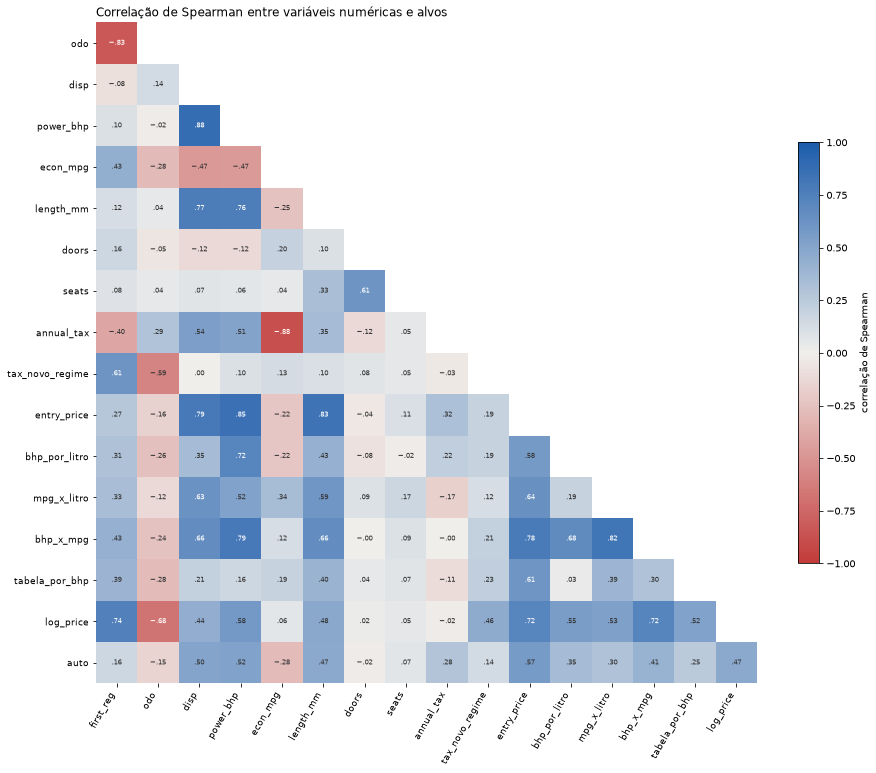

Pares mais parecidos (|correlação| >= 0,85): {('annual_tax', 'econ_mpg'): -0.88, ('power_bhp', 'disp'): 0.88} 

Correlação com os alvos (ordenada pela relação com o preço):


,log_price,auto
first_reg,0.74,0.16
bhp_x_mpg,0.72,0.41
entry_price,0.72,0.57
odo,-0.68,-0.15
power_bhp,0.58,0.52
bhp_por_litro,0.55,0.35
mpg_x_litro,0.53,0.30
tabela_por_bhp,0.52,0.25
length_mm,0.48,0.47
tax_novo_regime,0.46,0.14


In [44]:
from matplotlib.colors import LinearSegmentedColormap

insp = df_feat_insp.assign(log_price=np.log(df_feat_insp["price"]))
colunas_mapa = (["first_reg", "odo", "disp", "power_bhp", "econ_mpg", "length_mm", "doors", "seats",
                 "annual_tax", "tax_novo_regime", "entry_price"]
                + FEATURES_COMBINADAS + ["log_price", "auto"])
corr = insp[colunas_mapa].corr(method="spearman")
# Só o triângulo de baixo (o de cima é o espelho); sem a 1ª linha e a última coluna, que ficariam vazias
corr_metade = corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1)).iloc[1:, :-1]

# Divergente: azul (positiva) -> cinza (zero) -> vermelho (negativa)
cmap = LinearSegmentedColormap.from_list("div", ["#c23b3a", "#f0efec", "#1c5cab"])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_metade, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(corr_metade.shape[1]), corr_metade.columns, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(corr_metade.shape[0]), corr_metade.index, fontsize=9)
for i in range(corr_metade.shape[0]):
    for j in range(i + 1):
        v = corr_metade.iloc[i, j]
        ax.text(j, i, f"{v:.2f}".replace("0.", ".").replace("-.", "−."), ha="center", va="center",
                fontsize=6.5, color="white" if abs(v) > 0.6 else "#333333")
for lado in ax.spines.values():
    lado.set_visible(False)
ax.set_title("Correlação de Spearman entre variáveis numéricas e alvos", loc="left", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.6, label="correlação de Spearman")
plt.tight_layout()
plt.show()

# Pares de variáveis (sem os alvos) que carregam quase a mesma informação
feats = colunas_mapa[:-2]
pares = corr.loc[feats, feats].where(np.tril(np.ones((len(feats), len(feats)), dtype=bool), k=-1)).stack()
print("Pares mais parecidos (|correlação| >= 0,85):",
      pares[pares.abs() >= 0.85].sort_values(key=abs, ascending=False).round(2).to_dict(), "\n")

print("Correlação com os alvos (ordenada pela relação com o preço):")
corr.loc[colunas_mapa[:-2], ["log_price", "auto"]].sort_values("log_price", key=abs, ascending=False).round(2)

**Leitura:**

- **Redundâncias:** `annual_tax` × `econ_mpg` (−0,88: o imposto mede emissões, que dependem do consumo) e `power_bhp` × `disp` (+0,88: motores maiores são mais potentes).
- **Preço:** as relações mais fortes são ano de registro (+0,74), `entry_price` e `bhp_x_mpg` (+0,72) e quilometragem (−0,68).
- **Câmbio:** `entry_price` (+0,57), potência (+0,52) e cilindrada (+0,50).
- `mpg_x_litro` tem correlação moderada com o câmbio (+0,30), mas foi a feature que, sozinha, mais ajudou o Modelo 2 na régua. Correlação e ganho real respondem a perguntas diferentes, e por isso usamos as duas.

### Resumo das features

| # | Feature | O que representa | Preço | Câmbio |
|---|---|---|---|---|
| 1 | `bhp_por_litro` | força do motor | ✓ | |
| 2 | `mpg_x_litro` | eficiência do motor | ✓ | ✓ |
| 3 | `bhp_x_mpg` | força × eficiência (tecnologia) | | ✓ |
| 4 | `tabela_por_bhp` | prêmio da marca | | ✓ |
| 5 | `entry_price` preenchido + flag | preço de tabela recuperado do mesmo modelo de carro | ✓ | |

**Confirmação:** um teste mais rigoroso, rodado **fora deste notebook** (longo demais para a apresentação), retirou uma feature por vez em 30 divisões e confirmou o conjunto numa base reservada: com estas 5 features, o modelo empata nos carros conhecidos e melhora nos inéditos (preço −0,8%, câmbio −1,0%).

**Escopo de validade:** em carros inéditos o erro é bem maior (na régua da Feature 5: 0,262 contra 0,195 no preço; 0,344 contra 0,241 no câmbio), e nenhuma feature resolve isso.

## Parte 4 — Bases e colunas de cada modelo

Antes dos modelos: remover duplicatas, fechar três decisões de colunas (cor, câmbio no preço, preço no câmbio), definir as listas finais de colunas (as únicas do notebook) e juntar tudo em `preparar()`. Os testes usam a régua da Parte 3.

### Anúncios duplicados

**O que vimos:** anúncios idênticos em tudo, exceto o `id`. Se uma cópia cair no treino e a outra na validação, o erro medido fica otimista.

In [45]:
# Anúncios iguais em todas as colunas, exceto o id
colunas_sem_id = [c for c in df_feat.columns if c != "id"]
duplicada = df_feat.duplicated(subset=colunas_sem_id, keep=False)
print("linhas que têm pelo menos uma cópia idêntica (fora o id):", duplicada.sum())
print("cópias a remover (mantendo uma de cada):", df_feat.duplicated(subset=colunas_sem_id).sum())

# Tamanho de cada grupo de cópias (dropna=False: linhas com NaN também formam grupos)
tamanho_grupo = df_feat[duplicada].groupby(colunas_sem_id, dropna=False).size()
print("anúncios por grupo de cópias:", tamanho_grupo.value_counts().sort_index().to_dict())
print("quilometragem dos grupos com 5+ cópias:", sorted(tamanho_grupo[tamanho_grupo >= 5].reset_index()["odo"].tolist()))

# A base sem duplicatas, usada pelos dois modelos (o índice original é mantido)
df_sem_dup = df_feat.drop_duplicates(subset=colunas_sem_id)
print(f"\nbase: {len(df_feat)} -> sem duplicatas: {len(df_sem_dup)} | com preço: {df_sem_dup['price'].notna().sum()}"
      f" | com câmbio: {df_sem_dup['auto'].notna().sum()} ({df_sem_dup['auto'].mean():.1%} automáticos)")

linhas que têm pelo menos uma cópia idêntica (fora o id): 8984
cópias a remover (mantendo uma de cada): 4551
anúncios por grupo de cópias: {2: 4367, 3: 45, 4: 8, 5: 9, 6: 3, 20: 1}
quilometragem dos grupos com 5+ cópias: [1.0, 5.0, 6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 14.0, 20.0, 100.0, 100.0, 101.0]

base: 170150 -> sem duplicatas: 165599 | com preço: 164727 | com câmbio: 165485 (36.0% automáticos)


**Resultado:** 8.984 linhas têm cópia: **4.551 cópias excedentes** (2,7% da base). A maioria são pares (4.367 grupos: o mesmo carro anunciado duas vezes); os grupos com 5 ou mais cópias são todos de carros zero (estoque de concessionária).

**Decisão:** remover as cópias só nas bases de treino (`df_sem_dup`): ficam **165.599** anúncios (164.727 com preço; 165.485 com câmbio, 36,0% automáticos). Na previsão final, todo anúncio recebe previsão.

*Limitação:* a régua da Parte 3 rodou antes desta remoção; como as cópias são 2,7% da base e afetam os dois lados da comparação, o efeito deve ser pequeno.

### Decisão 1 — A cor (`paint`)

**Teste:** a cor ficou fora da régua da Parte 3; testamos agora, nos dois modelos.

In [46]:
# A cor vira "category" para o HistGradientBoosting tratá-la como categórica, como maker, fuel e body
aux["paint"] = aux["paint"].astype("category")
testar(["paint"])

,erro_sem,erro_com,diferença,divisões_que_melhoraram
modelo,,,,
preço,0.1950,0.1953,0.0004,0/4
câmbio,0.2406,0.2417,0.0011,0/4


**Resultado:** a cor **piora** os dois modelos, em **nenhuma** das 4 divisões ela ajuda: +0,0004 no preço e +0,0011 no câmbio. Com 14 cores (e 11% de faltantes), o modelo encontra padrões que não se repetem fora do treino.

**Decisão: `paint` fica fora dos dois modelos.**

### Decisão 2 — O câmbio no modelo de preço

**O risco:** se o modelo de preço usar o câmbio e o arquivo de avaliação vier **sem** ele, o modelo pode errar mais do que um que nunca o usou. **Teste:** o modelo de preço sem o câmbio contra o modelo com o câmbio, avaliado com o câmbio real, apagado e previsto pelo Modelo 2.

In [47]:
d = aux.loc[idx_preco]
com_cambio = BASE + ["auto"]
erro_sem_cambio = _cache[("log_price", tuple(BASE), "aleatoria")]   # já calculado pela régua da Parte 3

linhas = []
for i_tr, i_va in KFold(4, shuffle=True, random_state=0).split(d):
    tr, va = d.iloc[i_tr], d.iloc[i_va]
    preco = HistGradientBoostingRegressor(random_state=0, categorical_features="from_dtype").fit(tr[com_cambio], tr["log_price"])
    tr_c = tr[tr["auto"].notna()]   # o classificador não treina com alvo vazio
    cambio = HistGradientBoostingClassifier(random_state=0, categorical_features="from_dtype").fit(tr_c[BASE], tr_c["auto"])

    validacoes = {"com o câmbio real": va,
                  "câmbio apagado": va.assign(auto=np.nan),
                  "câmbio previsto pelo Modelo 2": va.assign(auto=(cambio.predict_proba(va[BASE])[:, 1] >= 0.5).astype(float))}
    linhas.append({nome: root_mean_squared_error(v["log_price"], preco.predict(v[com_cambio])) for nome, v in validacoes.items()})

erros_cambio_no_preco = pd.DataFrame(linhas)
pd.DataFrame({
    "erro médio": [erro_sem_cambio.mean()] + list(erros_cambio_no_preco.mean()),
    "divisões melhores que 'sem'": ["-"] + [f"{(erros_cambio_no_preco[c].to_numpy() < erro_sem_cambio).sum()}/4"
                                           for c in erros_cambio_no_preco],
}, index=["sem o câmbio"] + [f"treinado com o câmbio, avaliado: {c}" for c in erros_cambio_no_preco]).round(4)

,erro médio,divisões melhores que 'sem'
sem o câmbio,0.1950,-
"treinado com o câmbio, avaliado: com o câmbio real",0.1927,4/4
"treinado com o câmbio, avaliado: câmbio apagado",0.2027,0/4
"treinado com o câmbio, avaliado: câmbio previsto pelo Modelo 2",0.1948,2/4


**Resultado:**

- **Com o câmbio**, o erro cai de 0,1950 para **0,1927** (−0,0023, 4 de 4).
- **Se o câmbio sumir**, sobe para **0,2027**: 4% **pior** do que nunca ter usado o câmbio.
- **Preencher com o Modelo 2 não resolve:** 0,1948, empatado com o modelo sem câmbio (2 de 4).

**Decisão: duas versões do Modelo 1:** a principal (com câmbio) para os anúncios que o informam, e a reserva (sem câmbio) para os demais.

### Decisão 3 — O preço no modelo de câmbio

**Decisão: o Modelo 2 não usa o preço.** O preço é justamente o que o formulário sugere (pode não existir ainda, e a avaliação provavelmente não terá `price`), e o Modelo 1 usa o câmbio: um dependeria do outro em círculo. O custo é medido na Parte 5 (*Quanto custa deixar o preço de fora?*).

### Listas finais de colunas

Só entra o que existe no formulário quando o anúncio é criado. Ficam de fora `id`, `pct_of_list` (vazamento), `paint` (Decisão 1) e `ref_code` (usado só no preenchimento do `entry_price`). As travas (`assert`) param o notebook se uma coluna proibida entrar.

In [48]:
# Colunas originais (já limpas) que os dois modelos recebem: as mesmas da régua
NUMERICAS_ORIGINAIS = ["first_reg", "listed_yr", "listed_mo", "odo", "disp", "power_bhp", "econ_mpg",
                       "length_mm", "doors", "seats", "annual_tax", "tax_novo_regime", "entry_price"]
CATEGORICAS = ["maker", "fuel", "body"]

# Modelo 1 (preço): originais + câmbio + features aprovadas; e a versão reserva, sem o câmbio
FEATURES_PRECO = CATEGORICAS + NUMERICAS_ORIGINAIS + ["auto"] + FEATURES_NOVAS_PRECO
FEATURES_PRECO_SEM_CAMBIO = [c for c in FEATURES_PRECO if c != "auto"]
NUMERICAS_PRECO = [c for c in FEATURES_PRECO if c not in CATEGORICAS]

# Modelo 2 (câmbio): originais + features aprovadas (sem o preço e sem o próprio câmbio)
FEATURES_CAMBIO = CATEGORICAS + NUMERICAS_ORIGINAIS + FEATURES_NOVAS_CAMBIO
NUMERICAS_CAMBIO = [c for c in FEATURES_CAMBIO if c not in CATEGORICAS]

# Travas contra vazamento (o & devolve os elementos em comum; se não for vazio, há coluna proibida)
assert not {"id", "pct_of_list", "price", "log_price", "gearbox", "paint"} & set(FEATURES_PRECO + FEATURES_CAMBIO)
assert "auto" not in FEATURES_CAMBIO, "o alvo do Modelo 2 não pode ser coluna dele"

print(f"Modelo 1 (preço): {len(FEATURES_PRECO)} colunas | versão reserva: {len(FEATURES_PRECO_SEM_CAMBIO)}")
print(f"Modelo 2 (câmbio): {len(FEATURES_CAMBIO)} colunas")
print("só no preço:", sorted(set(FEATURES_PRECO) - set(FEATURES_CAMBIO)))
print("só no câmbio:", sorted(set(FEATURES_CAMBIO) - set(FEATURES_PRECO)))

Modelo 1 (preço): 20 colunas | versão reserva: 19
Modelo 2 (câmbio): 19 colunas
só no preço: ['auto', 'bhp_por_litro', 'entry_price_imputado']
só no câmbio: ['bhp_x_mpg', 'tabela_por_bhp']


**Resultado:** 20 colunas no Modelo 1 (19 na versão reserva) e 19 no Modelo 2. A diferença entre os dois é exatamente o que decidimos: só no preço, o câmbio, a potência por litro e a flag do `entry_price` preenchido; só no câmbio, a potência × consumo e o preço de tabela por cavalo.

### O pipeline: a função `preparar()`

`preparar()` = `limpar()` + `criar_features()`: a mesma função para o treino e para o arquivo de avaliação. A `EstatisticasRef` fica de fora (precisa de `fit` no treino, na Parte 5). Verificamos que ela reproduz os passos separados e aguenta o arquivo simulado.

In [49]:
def preparar(df_bruto):
    """Arquivo cru -> colunas limpas + features linha a linha. A MESMA função para o treino e para a avaliação."""
    return criar_features(limpar(df_bruto))


# Verificação 1: o mesmo resultado dos passos separados (compara valor por valor; para com erro se houver diferença)
pd.testing.assert_frame_equal(preparar(df), df_feat)

# Verificação 2: o arquivo de avaliação simulado passa pelo pipeline inteiro
teste_preparar = preparar(avaliacao_fake)
faltando = sorted(c for c in set(FEATURES_PRECO + FEATURES_CAMBIO) if c not in teste_preparar.columns)
assert faltando == ["entry_price_imputado"], "só a flag da EstatisticasRef pode faltar aqui"
print("linhas:", len(avaliacao_fake), "->", len(teste_preparar), "| colunas que ainda faltam:", faltando)

linhas: 300 -> 300 | colunas que ainda faltam: ['entry_price_imputado']


**Resultado:** as duas verificações passaram: `preparar()` reproduz exatamente os passos separados e aguenta o arquivo simulado sem perder nenhuma linha.

### Resumo das decisões de bases e colunas

| Decisão | Evidência |
|---|---|
| Remover 4.551 cópias, só das bases de treino | 2,7% da base: pares de reanúncios e estoque de carros zero |
| `paint` fora dos dois modelos | Piorou o preço (+0,0004) e o câmbio (+0,0011), em 0 de 4 divisões |
| Câmbio no Modelo 1, com uma versão reserva sem câmbio | Com: −0,0023 (4/4). Se sumir na avaliação: 4% pior. Preencher com o Modelo 2 empata com não usar |
| Preço fora do Modelo 2 | Motivos de uso (formulário e dependência circular); o custo é medido na Parte 5 |
| Listas de colunas definidas uma única vez | A Parte 5 usa estas listas; as travas impedem colunas proibidas |
| `preparar()` = `limpar()` + `criar_features()` | Mesmo resultado dos passos separados; aguenta o arquivo simulado |

## Parte 5 — Modelos


Os dois modelos seguem a mesma estrutura: carros "conhecidos" e "inéditos", baseline, laços de configurações, escolha pela média de conhecido e inédito, teste usado uma vez, análise de erros e escopo de validade.

**Reprodutibilidade:** todos os modelos têm semente fixa, e as saídas foram conferidas em dois computadores. Só o **tempo** muda (por isso os textos não citam tempos exatos). O Ridge, que variava na 4ª casa decimal, agora usa a solução exata, e o `requirements.txt` fixa as versões das bibliotecas.

### Modelo 1 — Preço



#### Divisão treino / validação / teste

**Divisão:** validação e teste têm duas partes, porque a avaliação tem outra composição: **"conhecido"** (anúncios sorteados de modelos de carro que estão no treino) e **"inédito"** (`ref_code`s inteiros fora do treino).

**Contra vazamento:** duplicatas removidas antes; o teste "conhecido" sai só de anúncios fora das amostras da régua; a `EstatisticasRef` aprende só no treino; o teste é usado uma única vez. *Limitação:* os `ref_code`s do teste inédito tiveram outros anúncios na amostra da régua.

In [50]:
# divisao 
from sklearn.model_selection import GroupShuffleSplit

# A base sem duplicatas (df_sem_dup) vem da Parte 4: as duplicatas saem ANTES de dividir
base_preco = df_sem_dup[df_sem_dup["price"].notna()]

# Anúncios que a régua de features já usou
usadas_na_regua = set(idx_preco) | set(idx_cambio)


def separar(d, frac_grupos, n_conhecido, semente):
    """Tira de d duas partes:
    - 'inédito': ref_codes inteiros (fração frac_grupos dos ref_codes)
    - 'conhecido': n_conhecido anúncios sorteados entre os que a régua NÃO usou
    Devolve (resto, conhecido, inédito)."""
    gss = GroupShuffleSplit(n_splits=1, test_size=frac_grupos, random_state=semente)
    i_resto, i_inedito = next(gss.split(d, groups=d["ref_code"]))
    resto, inedito = d.iloc[i_resto], d.iloc[i_inedito]

    candidatos = resto[~resto.index.isin(usadas_na_regua)]
    conhecido = candidatos.sample(n=n_conhecido, random_state=semente)
    resto = resto.drop(conhecido.index)
    return resto, conhecido, inedito


# Teste primeiro (fica guardado até o final), depois a validação
dev, teste_conhecido, teste_inedito = separar(base_preco, 0.10, 15_000, semente=42)
treino, val_conhecido, val_inedito = separar(dev, 0.10, 15_000, semente=7)

# Trava: nenhum ref_code "inédito" pode aparecer no treino
assert not set(val_inedito["ref_code"]) & set(treino["ref_code"])
assert not set(teste_inedito["ref_code"]) & set(dev["ref_code"])

for nome, parte in [("treino", treino), ("val conhecido", val_conhecido), ("val inédito", val_inedito),
                    ("teste conhecido", teste_conhecido), ("teste inédito", teste_inedito)]:
    print(f"{nome:16s} {len(parte):7d} anúncios | {parte['ref_code'].nunique():3d} ref_codes")

treino             99322 anúncios | 401 ref_codes
val conhecido      15000 anúncios | 365 ref_codes
val inédito        19776 anúncios |  46 ref_codes
teste conhecido    15000 anúncios | 399 ref_codes
teste inédito      15629 anúncios |  52 ref_codes


In [51]:
import time
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler

# As listas de colunas (FEATURES_PRECO, NUMERICAS_PRECO, CATEGORICAS...) vêm da Parte 4

# EstatisticasRef aprende a tabela de entry_price SÓ no treino
est_preco = EstatisticasRef().fit(treino)


def X_y(d):
    """Aplica a EstatisticasRef (já ajustada no treino) e separa X e y = log(price)."""
    d = est_preco.transform(d)
    return d[FEATURES_PRECO], np.log(d["price"])


X_tr, y_tr = X_y(treino)
X_vc, y_vc = X_y(val_conhecido)
X_vi, y_vi = X_y(val_inedito)


# --- Pré-processamento (fica DENTRO do Pipeline, então só aprende com o treino) ---

# Lineares (Ridge/Lasso): não aceitam NaN e penalizam coeficientes, então precisam de
# imputação + escala + one-hot. Log nas numéricas muito assimétricas, como no log10 do projeto anterior.
NUM_LOG = ["odo", "entry_price", "power_bhp"]

# numericas: as colunas numéricas do modelo (o Modelo 2 passa as dele).
# denso=True devolve uma matriz comum em vez de esparsa: o Ridge passa a usar a solução exata e o Lasso
# fica muito mais rápido (ver Ridge e Lasso).
def preproc_linear(numericas=NUMERICAS_PRECO, denso=False):
    num_log = [c for c in NUM_LOG if c in numericas]
    num_sem_log = [c for c in numericas if c not in NUM_LOG]
    return ColumnTransformer([
        ("num_log", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                              ("imp", SimpleImputer(strategy="median", add_indicator=True)),
                              ("esc", StandardScaler())]), num_log),
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("esc", StandardScaler())]), num_sem_log),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=not denso))]), CATEGORICAS),
    ])

# Árvore e Random Forest: não precisam de escala; categorias viram números (0, 1, 2...)
def preproc_arvore(numericas=NUMERICAS_PRECO):
    return ColumnTransformer([
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="desconhecido")),
                          ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]),
         CATEGORICAS),
        ("num", SimpleImputer(strategy="median", add_indicator=True), numericas),
    ])

# HistGradientBoosting: aceita NaN sozinho; as categóricas só precisam virar códigos.
# Categoria nunca vista (ex.: marca nova) vira NaN em vez de dar erro.
def preproc_hgb():
    return ColumnTransformer([
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CATEGORICAS),
    ], remainder="passthrough")   # as categóricas ficam nas 3 primeiras colunas


# --- Avaliação ---
def metricas(modelo, X, y_log):
    """RMSE em log(price) + MAE em libras + MAPE em %."""
    p_log = modelo.predict(X)
    real, prev = np.exp(y_log), np.exp(p_log)
    return (root_mean_squared_error(y_log, p_log),
            mean_absolute_error(real, prev),
            mean_absolute_percentage_error(real, prev) * 100)


def treinar_e_validar(modelo, nome, config):
    """Treina no treino e mede no treino (para ver overfitting) e nas duas validações."""
    t0 = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    tempo = time.perf_counter() - t0

    rmse_tr, _, _ = metricas(modelo, X_tr, y_tr)
    rmse_c, mae_c, mape_c = metricas(modelo, X_vc, y_vc)
    rmse_i, mae_i, mape_i = metricas(modelo, X_vi, y_vi)
    return {"modelo": nome, "config": config,
            "RMSE_log treino": rmse_tr,
            "RMSE_log conhecido": rmse_c, "RMSE_log inédito": rmse_i,
            "RMSE_log médio": (rmse_c + rmse_i) / 2,
            "MAPE% conhecido": mape_c, "MAPE% inédito": mape_i,
            "MAE £ conhecido": mae_c, "MAE £ inédito": mae_i,
            "tempo (s)": tempo}

In [52]:
#baseline - tudo e melhor mas coloquei para ter 

from sklearn.dummy import DummyRegressor

# Ponto de partida: prever sempre a mediana do log(price) do treino. Qualquer modelo precisa superar isso.
res_base = pd.DataFrame([treinar_e_validar(DummyRegressor(strategy="median"), "Baseline (mediana)", "-")])
res_base.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Baseline (mediana),-,1.019,1.022,0.972,0.997,137.997,131.051,9685.134,8588.595,0.001


**Resultado:** prever sempre a mediana dá um RMSE em log de **≈ 1,0** (MAPE de 131–138%, erro médio de ~£9 mil). Esse é o ponto de partida: qualquer modelo que não fique bem abaixo disso não aprendeu nada útil.

In [53]:
#ridge   
from sklearn.linear_model import Lasso, Ridge

linhas = []
for alpha in [0.01, 0.1, 1, 10, 100, 1000]:
    # Matriz densa: o Ridge usa a solução exata (Cholesky). Com a matriz esparsa ele usava um método
    # iterativo, cujo resultado mudava na 4ª casa decimal de um computador para outro.
    pipe = Pipeline([("prep", preproc_linear(denso=True)), ("modelo", Ridge(alpha=alpha))])
    linhas.append(treinar_e_validar(pipe, "Ridge", f"alpha={alpha}"))

res_ridge = pd.DataFrame(linhas)
res_ridge.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Ridge,alpha=0.01,0.288,0.292,0.290,0.291,21.532,21.882,2666.249,3110.943,0.327
1,Ridge,alpha=0.1,0.288,0.292,0.290,0.291,21.532,21.877,2666.308,3106.348,0.330
2,Ridge,alpha=1,0.288,0.292,0.290,0.291,21.534,21.865,2666.052,3070.475,0.337
3,Ridge,alpha=10,0.289,0.292,0.291,0.291,21.570,21.796,2665.547,2855.701,0.322
4,Ridge,alpha=100,0.292,0.294,0.296,0.295,21.776,21.727,2698.673,2783.614,0.318
5,Ridge,alpha=1000,0.301,0.302,0.301,0.302,22.381,21.949,2731.128,2893.754,0.324


**Resultado:** o Ridge fica praticamente igual de alpha 0,01 a 10 (RMSE médio 0,291; o melhor é alpha = 1 por diferença na 4ª casa) e só piora com regularização forte (0,302 com 1000). Treino (0,288) e validação (0,292) quase iguais: não há overfitting para corrigir. O erro em inéditos (0,290) é igual ao de conhecidos: o modelo linear não decora modelos de carro, mas é limitado (~22% de erro).

In [54]:
# lasso 
# Com o alvo em log, alphas a partir de ~0,1 já zeram quase tudo (como no projeto anterior),
# então a faixa testada é mais baixa que a do Ridge
linhas = []
for alpha in [0.00001, 0.0001, 0.001, 0.01, 0.1]:
    # denso + precompute: o Lasso trabalha com a matriz X'X (125 x 125) em vez de percorrer os 99 mil
    # anúncios a cada passo. Dá o mesmo resultado e é ~100x mais rápido (antes levava ~60 s).
    pipe = Pipeline([("prep", preproc_linear(denso=True)),
                     ("modelo", Lasso(alpha=alpha, max_iter=5000, precompute=True))])
    linhas.append(treinar_e_validar(pipe, "Lasso", f"alpha={alpha}"))

res_lasso = pd.DataFrame(linhas)
res_lasso.round(3)

C:\Users\Antônio Dias\Desktop\insper 2026.2\insper AI\projeto1\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.196141e+02, tolerance: 1.022e+01
  model = cd_fast.enet_coordinate_descent_gram(


,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Lasso,alpha=1e-05,0.288,0.292,0.289,0.290,21.516,21.768,2662.392,3008.996,0.362
1,Lasso,alpha=0.0001,0.290,0.292,0.289,0.291,21.627,21.286,2674.974,2624.906,0.360
2,Lasso,alpha=0.001,0.301,0.303,0.310,0.306,22.352,22.391,2758.285,2921.964,0.361
3,Lasso,alpha=0.01,0.328,0.331,0.328,0.329,24.410,23.959,2969.058,3360.331,0.362
4,Lasso,alpha=0.1,0.390,0.392,0.378,0.385,30.024,26.701,3715.153,3760.769,0.357


**Resultado:** o melhor Lasso (**alpha = 0,00001**, 0,290) empata com o Ridge; a partir de 0,001 ele zera coeficientes úteis e piora (0,385 com 0,1). O `ConvergenceWarning` não muda a conclusão. *Velocidade:* com matriz densa e `precompute=True`, o mesmo resultado sai em menos de 1 s por alpha (antes, ~60 s).

**Conclusão sobre os lineares:** o limite é o formato, não a regularização: o preço depende de combinações não lineares (marca × idade × quilometragem).

In [55]:
# decision tree
from sklearn.tree import DecisionTreeRegressor

linhas = []
for depth in [4, 8, 12, 16, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore()),
                     ("modelo", DecisionTreeRegressor(max_depth=depth, random_state=42))])
    linhas.append(treinar_e_validar(pipe, "Decision Tree", f"max_depth={depth}"))

res_arvore = pd.DataFrame(linhas)
res_arvore.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Decision Tree,max_depth=4,0.441,0.437,0.434,0.435,35.342,34.367,4564.458,4314.222,0.341
1,Decision Tree,max_depth=8,0.288,0.292,0.345,0.318,21.969,26.498,2582.228,3659.059,0.468
2,Decision Tree,max_depth=12,0.200,0.232,0.342,0.287,16.663,26.670,1907.221,3827.639,0.581
3,Decision Tree,max_depth=16,0.131,0.224,0.365,0.295,15.173,27.885,1688.476,4015.966,0.683
4,Decision Tree,max_depth=20,0.076,0.235,0.389,0.312,15.538,29.460,1671.257,4111.616,0.778
5,Decision Tree,max_depth=None,0.010,0.246,0.397,0.321,16.320,30.009,1751.486,4173.978,0.840


**Resultado:** profundidade 4 = underfitting (0,437); 12 = melhor média (0,287); sem limite = overfitting (0,010 no treino contra 0,246 na validação). Conhecidos e inéditos vão em **direções opostas**: em conhecidos o erro melhora até 16 (0,224), em inéditos piora a partir de 8 (0,345 → 0,397). Por isso escolhemos pela **média**: a árvore escolhida é pior que o Ridge em inéditos (0,342 contra 0,290).

In [56]:
# random forest 
from sklearn.ensemble import RandomForestRegressor

# 100 árvores; max_features=0.5 = cada corte sorteia metade das colunas (deixa as árvores
# mais diferentes entre si e o treino mais rápido); n_jobs=-1 usa todos os núcleos
linhas = []
for depth in [10, 15, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore()),
                     ("modelo", RandomForestRegressor(n_estimators=100, max_depth=depth, max_features=0.5,
                                                      n_jobs=-1, random_state=42))])
    linhas.append(treinar_e_validar(pipe, "Random Forest", f"max_depth={depth}"))

res_rf = pd.DataFrame(linhas)
res_rf.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Random Forest,max_depth=10,0.202,0.209,0.280,0.245,15.263,20.530,1736.301,2938.008,1.385
1,Random Forest,max_depth=15,0.127,0.175,0.275,0.225,11.938,19.638,1273.669,2802.850,1.938
2,Random Forest,max_depth=20,0.083,0.172,0.272,0.222,11.487,19.460,1195.348,2782.390,2.426
3,Random Forest,max_depth=None,0.067,0.174,0.272,0.223,11.580,19.424,1200.271,2752.151,3.369


**Resultado:** o melhor é **max_depth = 20** (0,222), muito melhor que uma árvore só e quase igual sem limite (0,223). Mas a diferença entre conhecido (0,172) e inédito (0,272) é grande: ele também aprende muito do modelo de carro específico.

In [57]:
# HistGradientBoosting
# No boosting, o "tamanho" de cada árvore é controlado por max_leaf_nodes (número de folhas).
# O número de árvores é escolhido sozinho pelo early_stopping: ele separa 10% do TREINO
# e para quando o erro nesses 10% deixa de cair.
linhas = []
for folhas in [15, 31, 63, 127]:
    pipe = Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=folhas, learning_rate=0.1, max_iter=1000,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42))])
    linha = treinar_e_validar(pipe, "HistGradientBoosting", f"max_leaf_nodes={folhas}")
    linha["config"] += f" ({pipe.named_steps['modelo'].n_iter_} árvores)"
    linhas.append(linha)

res_hgb = pd.DataFrame(linhas)
res_hgb.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,HistGradientBoosting,max_leaf_nodes=15 (970 árvores),0.150,0.165,0.224,0.195,11.477,15.987,1310.125,2170.117,2.763
1,HistGradientBoosting,max_leaf_nodes=31 (784 árvores),0.139,0.165,0.223,0.194,11.298,16.039,1276.144,2113.055,3.254
2,HistGradientBoosting,max_leaf_nodes=63 (461 árvores),0.135,0.165,0.234,0.199,11.246,16.692,1259.427,2267.962,3.050
3,HistGradientBoosting,max_leaf_nodes=127 (266 árvores),0.131,0.165,0.233,0.199,11.207,16.937,1250.123,2278.801,3.208


**Resultado:** é o melhor modelo. Em conhecidos as 4 configurações empatam (0,165); em inéditos, árvores menores generalizam melhor (15 e 31 folhas: 0,224 e 0,223; 63 e 127: 0,234 e 0,233). Escolhemos **max_leaf_nodes = 31** (784 árvores, RMSE médio **0,194**), empatado com 15 folhas.

#### Rede neural (MLP)

Rede com duas camadas escondidas (ReLU), treinada por gradiente descendente (Adam) + backpropagation sobre o erro em `log(price)`, com parada antecipada (10% do treino) e penalidade nos pesos. Usa o mesmo `preproc_linear()` do Ridge, com o alvo padronizado. Testamos 32-16 e 64-32 neurônios, com o cálculo limitado a 4 núcleos (`threadpool_limits`) para o tempo ficar estável.

In [58]:
# Rede neural (MLP): gradiente descendente (Adam) + backpropagation
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from threadpoolctl import threadpool_limits

threadpool_limits(limits=4, user_api="blas")   # 4 núcleos para o cálculo de matrizes (ver texto acima)


def modelo_mlp(camadas):
    """MLP com parada antecipada; o alvo log(price) também é padronizado."""
    rede = MLPRegressor(hidden_layer_sizes=camadas, activation="relu", solver="adam", learning_rate_init=1e-3,
                        alpha=1e-4, batch_size=256, max_iter=200, early_stopping=True, validation_fraction=0.1,
                        n_iter_no_change=10, random_state=42)
    return TransformedTargetRegressor(regressor=Pipeline([("prep", preproc_linear()), ("modelo", rede)]),
                                      transformer=StandardScaler())


linhas = []
for camadas in [(32, 16), (64, 32)]:
    modelo = modelo_mlp(camadas)
    linha = treinar_e_validar(modelo, "Rede neural (MLP)", f"camadas={camadas}")
    linha["config"] += f" ({modelo.regressor_.named_steps['modelo'].n_iter_} épocas)"
    linhas.append(linha)

res_mlp = pd.DataFrame(linhas)

# Configuração usada daqui em diante (cenário temporal e Modelo 2): ver o resultado abaixo
CAMADAS_MLP = (32, 16)
res_mlp.round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s)
0,Rede neural (MLP),"camadas=(32, 16) (52 épocas)",0.172,0.180,0.239,0.209,12.70,17.709,1519.777,2368.067,11.143
1,Rede neural (MLP),"camadas=(64, 32) (65 épocas)",0.161,0.174,0.242,0.208,12.08,17.598,1462.185,2136.535,23.113


**Resultado:** as duas redes **empatam**: **0,209** (32-16) e **0,208** (64-32). A maior erra um pouco menos em conhecidos (0,174 contra 0,180) e a menor em inéditos (0,239 contra 0,242). *(A 128-64, testada antes, também deu 0,209.)*

**Decisão de tamanho:** no empate, a mais simples e rápida: **32-16** (menos da metade do tempo), usada no cenário temporal e no Modelo 2 (`CAMADAS_MLP`).

**Comparação:** melhor que o Random Forest na média (0,208–0,209 contra 0,222), por errar menos em inéditos (0,239–0,242 contra 0,272); pior que o boosting nos dois casos. Fica como **segundo melhor modelo**.

#### Boosting mais regularizado

**Por que testar:** o ponto fraco do boosting são os inéditos. Testamos regras mais gerais: `min_samples_leaf = 50`, `l2_regularization = 1` e taxa de aprendizado menor (0,05), mantendo 31 folhas.

In [59]:
# HistGradientBoosting regularizado: folhas com pelo menos 50 anúncios + penalidade L2
linhas = []
for nome, params in [
    ("lr=0.1, 31 folhas, l2=1, min 50/folha", dict(learning_rate=0.1, max_iter=1000)),
    ("lr=0.05, 31 folhas, l2=1, min 50/folha", dict(learning_rate=0.05, max_iter=2000)),
]:
    pipe = Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=31, l2_regularization=1.0, min_samples_leaf=50,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42, **params))])
    linha = treinar_e_validar(pipe, "HGB regularizado", nome)
    linha["config"] += f" ({pipe.named_steps['modelo'].n_iter_} árvores)"
    linhas.append(linha)

res_hgb_reg = pd.DataFrame(linhas)

# Lado a lado com as configurações anteriores do boosting
colunas = ["modelo", "config", "RMSE_log treino", "RMSE_log conhecido", "RMSE_log inédito", "RMSE_log médio",
           "MAPE% conhecido", "MAPE% inédito", "tempo (s)"]
pd.concat([res_hgb, res_hgb_reg], ignore_index=True)[colunas].round(3)

,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,tempo (s)
0,HistGradientBoosting,max_leaf_nodes=15 (970 árvores),0.150,0.165,0.224,0.195,11.477,15.987,2.763
1,HistGradientBoosting,max_leaf_nodes=31 (784 árvores),0.139,0.165,0.223,0.194,11.298,16.039,3.254
2,HistGradientBoosting,max_leaf_nodes=63 (461 árvores),0.135,0.165,0.234,0.199,11.246,16.692,3.050
3,HistGradientBoosting,max_leaf_nodes=127 (266 árvores),0.131,0.165,0.233,0.199,11.207,16.937,3.208
4,HGB regularizado,"lr=0.1, 31 folhas, l2=1, min 50/folha (668 árv...",0.145,0.165,0.231,0.198,11.306,16.331,3.166
5,HGB regularizado,"lr=0.05, 31 folhas, l2=1, min 50/folha (1156 á...",0.147,0.164,0.224,0.194,11.300,15.943,4.157


**Resultado:** não melhora. Com taxa 0,05: **0,194**, empatado com o boosting de 31 folhas (e com mais árvores: 1.156). Com taxa 0,1: piora em inéditos (0,231).

**Decisão:** fica o **boosting de 31 folhas**, mais simples e mais rápido. *Na tabela abaixo, a versão regularizada pode aparecer em primeiro por diferença na 4ª casa decimal.*

In [60]:
# tabela comparativa de todos os modelos
todos = pd.concat([res_base, res_ridge, res_lasso, res_arvore, res_rf, res_hgb, res_mlp, res_hgb_reg],
                  ignore_index=True)

# Para cada modelo, a configuração com menor RMSE_log médio (média de conhecido e inédito,
# porque não sabemos a proporção de carros inéditos na avaliação)
comparacao = (todos.loc[todos.groupby("modelo")["RMSE_log médio"].idxmin()]
                   .sort_values("RMSE_log médio")
                   .reset_index(drop=True))

# Tradução do RMSE em log para "erro típico em %": exp(0,20) - 1 ≈ 22%
comparacao["erro típico % conhecido"] = (np.exp(comparacao["RMSE_log conhecido"]) - 1) * 100
comparacao["erro típico % inédito"] = (np.exp(comparacao["RMSE_log inédito"]) - 1) * 100

comparacao.round(3)


,modelo,config,RMSE_log treino,RMSE_log conhecido,RMSE_log inédito,RMSE_log médio,MAPE% conhecido,MAPE% inédito,MAE £ conhecido,MAE £ inédito,tempo (s),erro típico % conhecido,erro típico % inédito
0,HGB regularizado,"lr=0.05, 31 folhas, l2=1, min 50/folha (1156 á...",0.147,0.164,0.224,0.194,11.300,15.943,1291.370,2121.882,4.157,17.819,25.077
1,HistGradientBoosting,max_leaf_nodes=31 (784 árvores),0.139,0.165,0.223,0.194,11.298,16.039,1276.144,2113.055,3.254,17.898,25.043
2,Rede neural (MLP),"camadas=(64, 32) (65 épocas)",0.161,0.174,0.242,0.208,12.080,17.598,1462.185,2136.535,23.113,18.954,27.430
3,Random Forest,max_depth=20,0.083,0.172,0.272,0.222,11.487,19.460,1195.348,2782.390,2.426,18.802,31.199
4,Decision Tree,max_depth=12,0.200,0.232,0.342,0.287,16.663,26.670,1907.221,3827.639,0.581,26.125,40.737
5,Lasso,alpha=1e-05,0.288,0.292,0.289,0.290,21.516,21.768,2662.392,3008.996,0.362,33.845,33.543
6,Ridge,alpha=1,0.288,0.292,0.290,0.291,21.534,21.865,2666.052,3070.475,0.337,33.868,33.637
7,Baseline (mediana),-,1.019,1.022,0.972,0.997,137.997,131.051,9685.134,8588.595,0.001,177.870,164.278


#### Comparação dos modelos

| Modelo | Melhor config | RMSE log conhecido | RMSE log inédito | RMSE log médio | MAPE conhecido | MAPE inédito |
|---|---|---|---|---|---|---|
| **HistGradientBoosting** | max_leaf_nodes = 31 | **0,165** | **0,223** | **0,194** | 11,3% | 16,0% |
| HGB regularizado | lr = 0,05, min 50/folha, l2 = 1 | 0,164 | 0,224 | 0,194 | 11,3% | 15,9% |
| Rede neural (MLP) | camadas = (64, 32); a 32-16 empata | 0,174 | 0,242 | 0,208 | 12,1% | 17,6% |
| Random Forest | max_depth = 20 | 0,172 | 0,272 | 0,222 | 11,5% | 19,5% |
| Decision Tree | max_depth = 12 | 0,232 | 0,342 | 0,287 | 16,7% | 26,7% |
| Ridge | alpha = 1 (0,01–10 empatam) | 0,292 | 0,290 | 0,291 | 21,5% | 21,9% |
| Lasso | alpha = 0,00001 | 0,292 | 0,289 | 0,290 | 21,5% | 21,8% |
| Baseline (mediana) | — | 1,022 | 0,972 | 0,997 | 138% | 131% |

**Leitura:**

1. Todos superam muito a baseline (de ~1,0 para no máximo 0,29).
2. Boosting e Random Forest são os melhores: capturam relações não lineares que Ridge e Lasso não capturam.
3. Todo modelo de árvore piora em inéditos, e quanto mais decora, maior a piora: árvore +47%, Random Forest +58%, boosting +35%.
4. Em libras, o Random Forest erra um pouco menos nos conhecidos (£1.195 contra £1.276), porque o erro em libras é dominado pelos carros caros; nosso critério é o erro relativo (log).

**Decisão: o Modelo 1 final é o HistGradientBoostingRegressor com max_leaf_nodes = 31**, o melhor em conhecidos e inéditos. Na validação, erra ~18% (erro típico) e 11% (MAPE) em conhecidos, e ~25% e 16% em inéditos (~35% a mais).

#### Cenário temporal: anúncios de 2021

**Por que testar:** a avaliação pode ser de outro período. Treinamos com os anúncios até 2020 e medimos nos de 2021 (todos de carros registrados em 2019). Não escolhe o modelo: só confirma a escolha.

In [61]:
# Cenário temporal: treina com anúncios até 2020 e mede nos anúncios de 2021 (o teste continua guardado)
desenvolvimento = pd.concat([treino, val_conhecido, val_inedito])
treino_ate_2020 = treino[treino["listed_yr"] < 2021]
anuncios_2021 = desenvolvimento[desenvolvimento["listed_yr"] == 2021]

est_temporal = EstatisticasRef().fit(treino_ate_2020)          # tabela do entry_price só com até 2020
X_ate_2020 = est_temporal.transform(treino_ate_2020)[FEATURES_PRECO]
y_ate_2020 = np.log(treino_ate_2020["price"])
X_2021 = est_temporal.transform(anuncios_2021)[FEATURES_PRECO]
y_2021 = np.log(anuncios_2021["price"])
print("treino até 2020:", len(X_ate_2020), "anúncios | anúncios de 2021:", len(X_2021),
      "| deles, de modelos de carro fora do treino:", (~anuncios_2021["ref_code"].isin(treino_ate_2020["ref_code"])).sum())

# Os melhores de cada família, com a configuração escolhida na validação
candidatos_temporais = {
    "Ridge (alpha=0.1)": Pipeline([("prep", preproc_linear(denso=True)), ("modelo", Ridge(alpha=0.1))]),
    "Random Forest (max_depth=20)": Pipeline([("prep", preproc_arvore()), ("modelo", RandomForestRegressor(
        n_estimators=100, max_depth=20, max_features=0.5, n_jobs=-1, random_state=42))]),
    "HistGradientBoosting (31 folhas)": Pipeline([("prep", preproc_hgb()), ("modelo", HistGradientBoostingRegressor(
        max_leaf_nodes=31, learning_rate=0.1, max_iter=1000, early_stopping=True, n_iter_no_change=20,
        categorical_features=list(range(len(CATEGORICAS))), random_state=42))]),
    "Rede neural (MLP 32-16)": modelo_mlp(CAMADAS_MLP),
}

linhas = []
for nome, modelo in candidatos_temporais.items():
    t0 = time.perf_counter()
    modelo.fit(X_ate_2020, y_ate_2020)
    rmse_log, mae, mape = metricas(modelo, X_2021, y_2021)
    linhas.append({"modelo": nome, "RMSE_log 2021": rmse_log, "MAPE% 2021": mape, "MAE £ 2021": mae,
                   "tempo (s)": time.perf_counter() - t0})

res_temporal = pd.DataFrame(linhas).set_index("modelo")
res_temporal.round(3)

treino até 2020: 93511 anúncios | anúncios de 2021: 7428 | deles, de modelos de carro fora do treino: 758


,RMSE_log 2021,MAPE% 2021,MAE £ 2021,tempo (s)
modelo,,,,
Ridge (alpha=0.1),0.237,19.164,4620.532,0.299
Random Forest (max_depth=20),0.183,13.553,3555.649,2.295
HistGradientBoosting (31 folhas),0.175,13.449,3442.377,2.862
Rede neural (MLP 32-16),0.230,16.164,4524.313,12.656


**Resultado** (7.428 anúncios de 2021; o treino tinha 93.511 anúncios até 2020):

| Modelo | RMSE log 2021 | MAPE 2021 | Erro médio (£) |
|---|---|---|---|
| **HistGradientBoosting** | **0,175** | **13,4%** | £3.442 |
| Random Forest | 0,183 | 13,6% | £3.556 |
| Rede neural (MLP 32-16) | 0,230 | 16,2% | £4.524 |
| Ridge | 0,237 | 19,2% | £4.621 |

- A escolha se confirma: o boosting também é o melhor em 2021.
- A rede é a que mais sofre (0,230, atrás até do Random Forest, 0,183): extrapola pior para combinações de anos que não viu.
- O erro em libras é maior porque os carros de 2021 são mais novos e caros.

**Escopo de validade:** o modelo continua útil para outro período (MAPE de 13,4%).

#### Modelo final e avaliação no teste

O boosting escolhido é retreinado com treino + validação e avaliado no teste **uma única vez**; nenhuma decisão é tomada a partir desse número.

In [62]:
# Treino + validação juntos (os ref_codes do teste inédito continuam fora: a trava da divisão garantiu isso)
treino_final = pd.concat([treino, val_conhecido, val_inedito])
est_final = EstatisticasRef().fit(treino_final)


def X_y_final(d, colunas):
    """Aplica a EstatisticasRef ajustada em treino+validação e separa X e y = log(price)."""
    d = est_final.transform(d)
    return d[colunas], np.log(d["price"])


def modelo_hgb():
    """A configuração vencedora da validação."""
    return Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingRegressor(
                         max_leaf_nodes=31, learning_rate=0.1, max_iter=1000,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42))])


# Treina o modelo principal (com câmbio)
X_trf, y_trf = X_y_final(treino_final, FEATURES_PRECO)
modelo_principal = modelo_hgb().fit(X_trf, y_trf)

# ÚNICA avaliação do modelo principal no teste
X_tc, y_tc = X_y_final(teste_conhecido, FEATURES_PRECO)
X_ti, y_ti = X_y_final(teste_inedito, FEATURES_PRECO)

linhas = []
for nome, X, y in [("treino + validação", X_trf, y_trf), ("teste conhecido", X_tc, y_tc), ("teste inédito", X_ti, y_ti)]:
    rmse_log, mae, mape = metricas(modelo_principal, X, y)
    linhas.append({"conjunto": nome, "anúncios": len(y), "RMSE_log": rmse_log,
                   "erro típico %": (np.exp(rmse_log) - 1) * 100, "MAPE %": mape, "MAE £": mae})

print("árvores escolhidas pelo early stopping:", modelo_principal.named_steps["modelo"].n_iter_)
resultado_teste = pd.DataFrame(linhas).set_index("conjunto").round(3)
resultado_teste

árvores escolhidas pelo early stopping: 1000


,anúncios,RMSE_log,erro típico %,MAPE %,MAE £
conjunto,,,,,
treino + validação,134098,0.138,14.790,9.681,1106.224
teste conhecido,15000,0.171,18.606,11.226,1405.837
teste inédito,15629,0.233,26.286,17.537,1645.336


**Resultado no teste (avaliado uma única vez):**

| Conjunto | RMSE log | Erro típico | MAPE | Erro médio (£) |
|---|---|---|---|---|
| Treino + validação | 0,138 | 14,8% | 9,7% | £1.106 |
| **Teste conhecido** | **0,171** | 18,6% | **11,2%** | £1.406 |
| **Teste inédito** | **0,233** | 26,3% | **17,5%** | £1.645 |

- **O teste confirma a validação**, um pouco pior (conhecido 0,165 → 0,171; inédito 0,223 → 0,233), como esperado depois de escolher o melhor entre vários modelos.
- **Sem overfitting grave:** 0,138 no treino.
- **Na prática:** erra ~11% em modelos de carro conhecidos e ~17,5% em inéditos.
- *O early stopping chegou a 1.000 árvores (784 na validação); não mudamos isso depois de ver o teste.*

#### Análise de erros: onde o modelo erra mais?


Erros do teste por tipo de carro, faixa de preço, idade e marca: **erro absoluto mediano (%)** e **viés mediano (%)** (positivo = superestima).

In [63]:
# Junta as previsões do teste com as informações de cada anúncio
partes = []
for tipo, d, X in [("conhecido", teste_conhecido, X_tc), ("inédito", teste_inedito, X_ti)]:
    p = d[["maker", "ref_code", "idade", "odo", "fuel", "body", "price"]].copy()
    p["tipo"] = tipo
    p["pred"] = np.exp(modelo_principal.predict(X))
    partes.append(p)
erros = pd.concat(partes)

erros["erro_pct"] = (erros["pred"] - erros["price"]) / erros["price"] * 100   # + superestima, - subestima
erros["erro_abs_pct"] = erros["erro_pct"].abs()


def tabela_erro(d, por):
    """Erro típico e viés por grupo."""
    return (d.groupby(por, observed=True)
             .agg(anuncios=("erro_pct", "size"),
                  erro_abs_mediano=("erro_abs_pct", "median"),
                  vies_mediano=("erro_pct", "median"))
             .round(1))


print("Por tipo de carro:")
print(tabela_erro(erros, "tipo"), "\n")

faixas_preco = [0, 2_000, 5_000, 10_000, 20_000, 50_000, np.inf]
nomes_preco = ["< £2k", "£2k–5k", "£5k–10k", "£10k–20k", "£20k–50k", "> £50k"]
erros["faixa_preco"] = pd.cut(erros["price"], faixas_preco, labels=nomes_preco)
print("Por faixa de preço real:")
print(tabela_erro(erros, "faixa_preco"), "\n")

faixas_idade = [-0.1, 1, 3, 5, 8, 12, np.inf]
nomes_idade = ["0–1 ano", "1–3", "3–5", "5–8", "8–12", "12+"]
erros["faixa_idade"] = pd.cut(erros["idade"], faixas_idade, labels=nomes_idade)
print("Por idade do carro:")
print(tabela_erro(erros, "faixa_idade"))

Por tipo de carro:
           anuncios  erro_abs_mediano  vies_mediano
tipo                                               
conhecido     15000               7.3          -0.3
inédito       15629              12.9          -0.6 

Por faixa de preço real:
             anuncios  erro_abs_mediano  vies_mediano
faixa_preco                                          
< £2k            3332              20.9           7.9
£2k–5k           5479              12.7          -1.8
£5k–10k          9439               9.2           0.0
£10k–20k         7846               8.0          -0.3
£20k–50k         3898               7.2          -2.3
> £50k            635               8.4          -5.5 

Por idade do carro:
             anuncios  erro_abs_mediano  vies_mediano
faixa_idade                                          
0–1 ano          4282               7.8           0.2
1–3              7462               8.5           0.1
3–5              4722               8.1           0.0
5–8              5967 

In [64]:
# Marcas com pelo menos 300 anúncios no teste, da que o modelo mais erra para a que menos erra
por_marca = tabela_erro(erros, "maker")
print("Por marca (300+ anúncios no teste):")
print(por_marca[por_marca["anuncios"] >= 300].sort_values("erro_abs_mediano", ascending=False), "\n")

print("Os 10 maiores erros (em %):")
erros.sort_values("erro_abs_pct", ascending=False).head(10)[
    ["maker", "tipo", "idade", "odo", "price", "pred", "erro_pct"]].round(0)

Por marca (300+ anúncios no teste):
               anuncios  erro_abs_mediano  vies_mediano
maker                                                  
Saab                542              19.6         -11.4
Renault            1949              15.8         -11.8
Nissan             2978              12.4          10.8
Hyundai            1103              11.6           0.2
Fiat                611              10.9          -0.4
Citroen            1269              10.5          -6.2
Volvo               866               9.7          -3.9
Ford               4317               9.7           1.7
Mercedes-Benz       659               9.6           0.7
SKODA              1257               9.5          -1.8
Audi               2992               9.3          -3.3
Vauxhall           1910               9.0           1.0
Honda               339               8.6          -0.1
Volkswagen         1930               8.5          -2.5
Porsche             717               8.2          -1.3
BMW         

,maker,tipo,idade,odo,price,pred,erro_pct
165996,Westfield,conhecido,12.0,2009.0,7995.0,60667.0,659.0
90257,Renault,inédito,16.0,78451.0,100.0,730.0,630.0
147901,Vauxhall,conhecido,12.0,60000.0,250.0,1732.0,593.0
113236,Saab,inédito,11.0,80000.0,350.0,2287.0,553.0
26105,Ford,inédito,8.0,105000.0,675.0,3910.0,479.0
107261,Audi,conhecido,13.0,126541.0,500.0,2576.0,415.0
90932,Renault,inédito,12.0,NaN,175.0,870.0,397.0
92204,Reva,inédito,12.0,16231.0,1995.0,8293.0,316.0
49338,Kia,conhecido,14.0,59398.0,350.0,1445.0,313.0
5898,Daihatsu,inédito,11.0,94000.0,490.0,2011.0,310.0


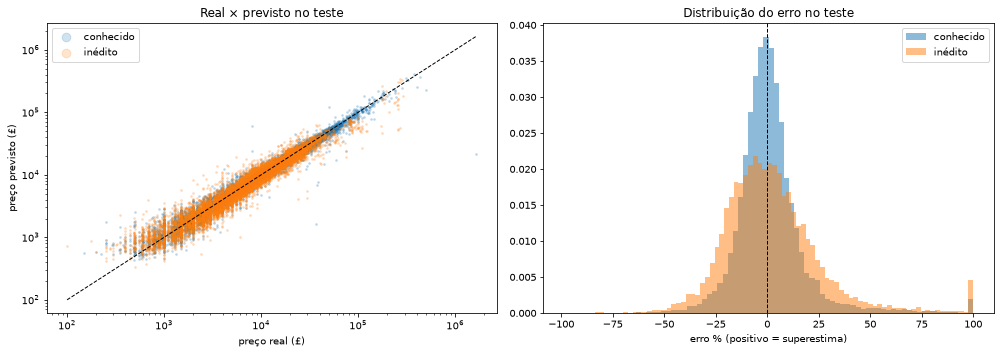

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Preço real × previsto (escala log). Pontos na linha tracejada = acerto perfeito
for tipo, cor in [("conhecido", "tab:blue"), ("inédito", "tab:orange")]:
    d = erros[erros["tipo"] == tipo]
    axes[0].scatter(d["price"], d["pred"], s=3, alpha=0.2, color=cor, label=tipo)
lim = [erros["price"].min(), erros["price"].max()]
axes[0].plot(lim, lim, "k--", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("preço real (£)")
axes[0].set_ylabel("preço previsto (£)")
axes[0].set_title("Real × previsto no teste")
axes[0].legend(markerscale=5)

# 2) Distribuição do erro % (cortada em ±100% para o gráfico ficar legível)
for tipo, cor in [("conhecido", "tab:blue"), ("inédito", "tab:orange")]:
    axes[1].hist(erros.loc[erros["tipo"] == tipo, "erro_pct"].clip(-100, 100), bins=80,
                 alpha=0.5, density=True, color=cor, label=tipo)
axes[1].axvline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("erro % (positivo = superestima)")
axes[1].set_title("Distribuição do erro no teste")
axes[1].legend()

plt.tight_layout()
plt.show()

**Resultado da análise de erros:**

- **Conhecido × inédito:** o erro mediano quase dobra nos inéditos (7,3% → 12,9%), sem viés nos dois (−0,3% e −0,6%).
- **Preço:** erra mais nos baratos: abaixo de £2 mil, erro de 20,9% e viés de **+7,9%** (superestima); entre £5 mil e £50 mil, 7–9% sem viés; acima de £50 mil, viés de **−5,5%**. É o típico "puxar para o meio".
- **Idade:** ~8% até 8 anos; **14,1%** (8–12) e **20,1%** (12+). Em carros velhos, o preço depende do estado de conservação, que a base não tem.
- **Marca:** Saab (19,6%, viés −11,4%), Renault (15,8%, −11,8%) e Nissan (12,4%, +10,8%) erram mais; Jaguar, Toyota e Mazda, menos (5,9–7,0%).
- **Maiores erros:** quase todos carros de £100–£700 ("para desmanche"), previstos entre £700 e £4.000. Exceções: Westfield (kit esportivo, £7.995 previsto em £60.667) e Reva (microcarro elétrico, £1.995 previsto em £8.293).
- **Gráficos:** os pontos seguem a diagonal; o erro é centrado em zero e mais largo nos inéditos. O ponto isolado é um hipercarro de ~£1,6 milhão.

#### Versão reserva do Modelo 1: sem o câmbio


**Por quê:** se o anúncio não informar o câmbio, o modelo principal erra mais (Parte 4, *Decisão 2*). A versão **reserva** é igual, mas sem `auto`; cada anúncio usa a principal se tiver câmbio e a reserva se não tiver. A tabela abaixo só documenta o efeito no teste.

In [66]:
# Treina a versão reserva com o mesmo treino + validação
X_trf_sc, _ = X_y_final(treino_final, FEATURES_PRECO_SEM_CAMBIO)
modelo_reserva = modelo_hgb().fit(X_trf_sc, y_trf)

linhas = []
for tipo, d, X, y in [("conhecido", teste_conhecido, X_tc, y_tc), ("inédito", teste_inedito, X_ti, y_ti)]:
    X_sem_cambio = X.copy()
    X_sem_cambio["auto"] = np.nan          # simula um arquivo de avaliação sem o câmbio

    linhas.append({
        "teste": tipo,
        "principal, com câmbio": metricas(modelo_principal, X, y)[0],
        "principal, câmbio apagado": metricas(modelo_principal, X_sem_cambio, y)[0],
        "reserva (nunca usou câmbio)": metricas(modelo_reserva, X[FEATURES_PRECO_SEM_CAMBIO], y)[0],
    })

print("RMSE em log(price) no teste:")
pd.DataFrame(linhas).set_index("teste").round(4)

RMSE em log(price) no teste:


,"principal, com câmbio","principal, câmbio apagado",reserva (nunca usou câmbio)
teste,,,
conhecido,0.1706,0.1848,0.1713
inédito,0.2334,0.2387,0.2365


In [67]:
# a função que será usada na FINAL — PREDICTION SECTION (preparar() vem da Parte 4)
def prever_preco(d_preparado):
    """Recebe a base já passada por preparar() e devolve o preço sugerido (£).
    Anúncios com câmbio -> modelo principal; sem câmbio -> modelo reserva."""
    d = est_final.transform(d_preparado)
    pred = np.exp(modelo_reserva.predict(d[FEATURES_PRECO_SEM_CAMBIO]))

    tem_cambio = d["auto"].notna().to_numpy()
    if tem_cambio.any():
        pred[tem_cambio] = np.exp(modelo_principal.predict(d.loc[tem_cambio, FEATURES_PRECO]))
    return pred


# Teste rápido: roda no arquivo de avaliação simulado (sem price e sem gearbox)
p = prever_preco(preparar(avaliacao_fake))
print("previsões:", len(p), "| sem NaN:", not np.isnan(p).any(), "| exemplo:", p[:5].round(0))

previsões: 300 | sem NaN: True | exemplo: [ 3632.  2699.  5673. 32723.  6459.]


**Resultado (RMSE em log no teste):**

| Teste | Principal, com câmbio | Principal, câmbio apagado | Reserva (sem câmbio) |
|---|---|---|---|
| Conhecido | **0,1706** | 0,1848 | 0,1713 |
| Inédito | **0,2334** | 0,2387 | 0,2365 |

- Sem o câmbio, a principal piora (0,1706 → 0,1848 em conhecidos, +8%); a reserva recupera quase tudo (0,1713).
- O câmbio em si ajuda pouco (0,0007 em conhecidos, 0,003 em inéditos): o perigo é **treinar com ele e não recebê-lo**.

**Decisão confirmada:** `prever_preco()` escolhe a versão automaticamente (testada no arquivo simulado: 300 previsões, nenhuma vazia).

#### Resumo do Modelo 1 — Preço

**Modelo final:** HistGradientBoostingRegressor (max_leaf_nodes = 31), prevendo `log(price)`, treinado em treino + validação. Existem duas versões: a **principal**, com o câmbio, e a **reserva**, sem ele.

**Pontuações de todos os modelos testados (validação, RMSE em log, média de conhecido e inédito):**

| Modelo | Melhor config | RMSE médio |
|---|---|---|
| **HistGradientBoosting** | max_leaf_nodes = 31 | **0,194** |
| HGB regularizado | lr = 0,05, min 50/folha, l2 = 1 | 0,194 (empate) |
| Rede neural (MLP) | camadas = (64, 32); a 32-16 empata (0,209) | 0,208 |
| Random Forest | max_depth = 20 | 0,222 |
| Decision Tree | max_depth = 12 | 0,287 |
| Ridge | alpha = 1 (0,01–10 empatam) | 0,291 |
| Lasso | alpha = 0,00001 | 0,290 |
| Baseline (mediana) | — | 0,997 |

**Cenário temporal (treino até 2020, anúncios de 2021):** HistGradientBoosting 0,175 (MAPE 13,4%), Random Forest 0,183, rede neural 0,230, Ridge 0,237.

**Desempenho final (teste, usado uma única vez):** MAPE de **11,2%** em modelos de carro conhecidos e **17,5%** em modelos inéditos.

**Principais decisões:** alvo em log; validação e teste com carros conhecidos e inéditos, escolha pela média dos dois; `pct_of_list` removida e duplicatas fora antes da divisão; versão reserva sem câmbio; rede neural (2º lugar) e boosting regularizado (empate) testados.

**Escopo de validade (onde confiar no modelo):**
- ✅ **Confiável:** carros de £5 mil a £50 mil, com até 8 anos, de modelos já presentes na base (erro mediano de ~7–9%).
- ⚠️ **Menos confiável:** modelos de carro inéditos (erro ~75% maior), anúncios de outro período (MAPE de 13,4% em 2021), carros com mais de 8 anos e marcas como Saab, Renault e Nissan.
- ❌ **Não confiável:** carros abaixo de £2 mil (o preço depende do estado do carro, que não está na base; o modelo superestima), hipercarros e marcas raras (Westfield, Reva), que têm poucos exemplos.

**Limitações:**
- A base não tem o estado de conservação, o histórico de manutenção nem os opcionais, fatores que pesam muito no preço de carros velhos e baratos;
- A régua de escolha de features usou parte dos anúncios que depois foram para o teste "inédito" (não os do teste "conhecido"), então o resultado inédito pode ser levemente otimista;
- O modelo puxa os extremos para o meio: carros muito baratos são superestimados e carros caros, subestimados.

In [68]:
# A frase-resumo do Modelo 1: "erra ~11% em carros conhecidos e ~17,5% em carros inéditos; erra mais nos carros baratos e velhos, porque o preço deles depende do estado do carro, que o anúncio não informa".
# Por que não aumentamos as árvores (o early stopping bateu em 1.000): o teste já tinha sido visto, e mudar o modelo depois disso seria escolher pelo teste.

### Modelo 2 — Câmbio (Automatic × Manual)

**O que o modelo faz:** estima a **probabilidade de ser automático** e a classe (`Automatic` se ≥ 50%). Serve para preencher o câmbio ou alertar quando o vendedor marcou algo improvável.

**Colunas:** as originais do Modelo 1 + `mpg_x_litro`, `bhp_x_mpg` e `tabela_por_bhp` (Parte 3). Ficam de fora o preço (Parte 4, Decisão 3), o `entry_price` preenchido (piorou o câmbio em inéditos), `pct_of_list` e `paint`.

#### Métricas do Modelo 2

**Métricas:** **log loss** (principal: mede a qualidade das probabilidades e pune certeza errada; menor é melhor), **AUC** (separação das classes; 0,5 = sorteio, 1 = perfeito) e **acurácia** (corte de 50%). A acurácia sozinha engana: responder sempre "Manual" já acerta 64%.

**Critério:** menor log loss média entre conhecido e inédito, como no Modelo 1.

#### Divisão treino / validação / teste

Usamos **os mesmos grupos do Modelo 1** (mesmos `ref_code`s inéditos e mesmos anúncios conhecidos), agora com os anúncios de câmbio conhecido. Os 914 sem preço vão para o treino ou para a parte inédita do seu `ref_code`.

In [69]:
base_cambio = df_sem_dup[df_sem_dup["auto"].notna()]

# Mesmos ref_codes inéditos e mesmos anúncios "conhecidos" do Modelo 1
refs_teste_ined = set(teste_inedito["ref_code"])
refs_val_ined = set(val_inedito["ref_code"])

eh_teste_conh = base_cambio.index.isin(teste_conhecido.index)
eh_val_conh = base_cambio.index.isin(val_conhecido.index)
eh_teste_ined = base_cambio["ref_code"].isin(refs_teste_ined).to_numpy()
# (no Modelo 1, a validação inédita saiu do que sobrou depois de separar o teste; mantemos a mesma prioridade)
eh_val_ined = base_cambio["ref_code"].isin(refs_val_ined).to_numpy() & ~eh_teste_conh

teste_conhecido_cambio = base_cambio[eh_teste_conh]
teste_inedito_cambio = base_cambio[eh_teste_ined]
val_conhecido_cambio = base_cambio[eh_val_conh]
val_inedito_cambio = base_cambio[eh_val_ined]
treino_cambio = base_cambio[~(eh_teste_conh | eh_teste_ined | eh_val_conh | eh_val_ined)]

# Travas: cada anúncio em uma parte só, e nenhum ref_code inédito no treino
partes_cambio = [treino_cambio, val_conhecido_cambio, val_inedito_cambio, teste_conhecido_cambio, teste_inedito_cambio]
assert sum(len(p) for p in partes_cambio) == len(base_cambio)
assert not set(val_inedito_cambio["ref_code"]) & set(treino_cambio["ref_code"])
assert not set(teste_inedito_cambio["ref_code"]) & set(treino_cambio["ref_code"])

for nome, parte in zip(["treino", "val conhecido", "val inédito", "teste conhecido", "teste inédito"], partes_cambio):
    print(f"{nome:16s} {len(parte):7d} anúncios | {parte['ref_code'].nunique():3d} ref_codes"
          f" | {parte['auto'].mean() * 100:4.1f}% automático")

treino            100122 anúncios | 401 ref_codes | 38.0% automático
val conhecido      14989 anúncios | 365 ref_codes | 38.1% automático
val inédito        19763 anúncios |  46 ref_codes | 34.1% automático
teste conhecido    14988 anúncios | 398 ref_codes | 37.9% automático
teste inédito      15623 anúncios |  52 ref_codes | 22.1% automático


In [70]:
from sklearn.metrics import accuracy_score, roc_auc_score

# As colunas do Modelo 2 (FEATURES_CAMBIO, NUMERICAS_CAMBIO) vêm da Parte 4


def X_y_cambio(d):
    """Separa X e y (1 = Automatic, 0 = Manual)."""
    return d[FEATURES_CAMBIO], d["auto"].astype(int)


X_tr_cambio, y_tr_cambio = X_y_cambio(treino_cambio)
X_vc_cambio, y_vc_cambio = X_y_cambio(val_conhecido_cambio)
X_vi_cambio, y_vi_cambio = X_y_cambio(val_inedito_cambio)


# Pré-processamento: as mesmas funções do Modelo 1, recebendo as colunas numéricas do Modelo 2:
# preproc_linear(NUMERICAS_CAMBIO), preproc_arvore(NUMERICAS_CAMBIO) e preproc_hgb() (este só codifica
# as 3 categóricas, que também são as primeiras colunas de FEATURES_CAMBIO).


# --- Avaliação ---
def metricas_cambio(modelo, X, y):
    """Log loss, AUC e acurácia (corte de 50%)."""
    proba = modelo.predict_proba(X)[:, 1]
    return log_loss(y, proba), roc_auc_score(y, proba), accuracy_score(y, proba >= 0.5)


def treinar_e_validar_cambio(modelo, nome, config):
    """Treina no treino do Modelo 2 e mede no treino e nas duas validações."""
    t0 = time.perf_counter()
    modelo.fit(X_tr_cambio, y_tr_cambio)
    tempo = time.perf_counter() - t0

    ll_tr, _, _ = metricas_cambio(modelo, X_tr_cambio, y_tr_cambio)
    ll_c, auc_c, acc_c = metricas_cambio(modelo, X_vc_cambio, y_vc_cambio)
    ll_i, auc_i, acc_i = metricas_cambio(modelo, X_vi_cambio, y_vi_cambio)
    return {"modelo": nome, "config": config,
            "logloss treino": ll_tr,
            "logloss conhecido": ll_c, "logloss inédito": ll_i,
            "logloss médio": (ll_c + ll_i) / 2,
            "AUC conhecido": auc_c, "AUC inédito": auc_i,
            "acurácia % conhecido": acc_c * 100, "acurácia % inédito": acc_i * 100,
            "tempo (s)": tempo}

**Resultado:**

| Parte | Anúncios | `ref_code`s | % automático |
|---|---|---|---|
| Treino | 100.122 | 401 | 38,0% |
| Validação "conhecido" | 14.989 | 365 | 38,1% |
| Validação "inédito" | 19.763 | 46 | 34,1% |
| Teste "conhecido" | 14.988 | 398 | 37,9% |
| Teste "inédito" | 15.623 | 52 | **22,1%** |

O teste "inédito" tem bem menos automáticos (22%) que o resto: os 52 `ref_code`s sorteados são de modelos mais populares. Simula bem uma avaliação com outra composição.

#### Baseline

Responde sempre a proporção de automáticos do treino (na prática, sempre "Manual").

In [71]:
from sklearn.dummy import DummyClassifier

res_base_cambio = pd.DataFrame([
    treinar_e_validar_cambio(DummyClassifier(strategy="prior"), "Baseline (proporção)", "-")])
res_base_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Baseline (proporção),-,0.664,0.664,0.645,0.655,0.5,0.5,61.925,65.901,0.002


**Resultado:** prever sempre 38% de chance de ser automático dá uma log loss de **0,664** (conhecido) e **0,645** (inédito). A acurácia é de **62% e 66%**, só por responder sempre "Manual". É exatamente o problema descrito nas métricas: acertar ~64% não significa ter aprendido nada.

#### Regressão logística com penalização L2 (o "Ridge" da classificação)

Modelo linear da classificação: soma ponderada das colunas → sigmoide → probabilidade. `C` é o inverso da regularização (C pequeno = forte).

In [72]:
from sklearn.linear_model import LogisticRegression

linhas_cambio, logisticas_cambio = [], {}
for C in [0.001, 0.01, 0.1, 1, 10]:
    pipe = Pipeline([("prep", preproc_linear(NUMERICAS_CAMBIO)),
                     ("modelo", LogisticRegression(C=C, max_iter=2000))])
    linhas_cambio.append(treinar_e_validar_cambio(pipe, "Logística L2", f"C={C}"))
    logisticas_cambio[C] = pipe

res_l2_cambio = pd.DataFrame(linhas_cambio)
res_l2_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Logística L2,C=0.001,0.422,0.424,0.398,0.411,0.876,0.887,82.747,82.771,0.476
1,Logística L2,C=0.01,0.390,0.392,0.349,0.371,0.891,0.914,83.868,85.200,0.699
2,Logística L2,C=0.1,0.376,0.378,0.318,0.348,0.898,0.926,84.128,88.635,1.027
3,Logística L2,C=1,0.373,0.376,0.314,0.345,0.900,0.926,84.275,88.119,1.602
4,Logística L2,C=10,0.373,0.376,0.314,0.345,0.900,0.926,84.202,88.074,1.657


**Resultado:** com C = 1 ou 10 (empate), a log loss média cai de 0,655 para **0,345** (AUC 0,90–0,93, acurácia 84–88%). Regularização forte atrapalha (0,411 com C = 0,001), e treino e validação quase iguais (0,373 e 0,376) mostram que não há overfitting. Vai **melhor nos inéditos** (0,314) que nos conhecidos (0,376): não decora modelos de carro, e a validação inédita tem menos automáticos.

#### Regressão logística com penalização L1 (o "Lasso" da classificação)

Penalização L1 (como o Lasso): pode zerar os pesos de colunas pouco úteis.

In [73]:
# l1_ratio=1 é a L1 (o parâmetro `penalty` está obsoleto desde o scikit-learn 1.8 e enchia a saída de avisos).
# Só as penalidades fortes: com C >= 0,1 a L1 empatava com a L2 (log loss média 0,345-0,347),
# mas o solver levava de 3 s a 25 s por configuração.
# random_state: o liblinear embaralha os dados; sem semente, o resultado mudava de uma execução para outra.
linhas_cambio = []
for C in [0.001, 0.01]:
    pipe = Pipeline([("prep", preproc_linear(NUMERICAS_CAMBIO)),
                     ("modelo", LogisticRegression(C=C, l1_ratio=1, solver="liblinear", random_state=42))])
    linhas_cambio.append(treinar_e_validar_cambio(pipe, "Logística L1", f"C={C}"))
    coef = pipe.named_steps["modelo"].coef_
    linhas_cambio[-1]["config"] += f" ({(coef == 0).sum()} de {coef.size} pesos zerados)"

res_l1_cambio = pd.DataFrame(linhas_cambio)
res_l1_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Logística L1,C=0.001 (108 de 123 pesos zerados),0.455,0.456,0.447,0.451,0.858,0.848,82.067,81.536,0.505
1,Logística L1,C=0.01 (76 de 123 pesos zerados),0.391,0.392,0.354,0.373,0.891,0.909,83.821,87.355,1.119


**Resultado:** a L1 forte zera a maioria dos pesos (108 de 123 com C = 0,001; 76 com C = 0,01) e piora (0,451 e 0,373, contra 0,345 da L2). Com C ≥ 0,1 ela empatava com a L2, mas era muito mais lenta, então saiu. Nos lineares, o limite é o formato, não a regularização.

#### Quais colunas pesam mais no câmbio?

Com as numéricas padronizadas, os coeficientes da melhor logística são comparáveis: + puxa para automático, − para manual (com as outras colunas fixas).

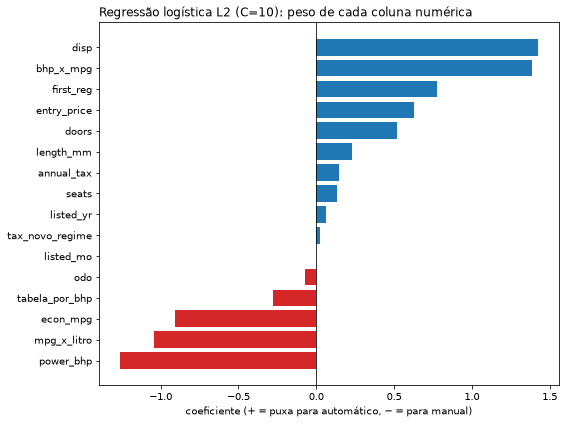

Colunas numéricas: {'power_bhp': -1.26, 'mpg_x_litro': -1.04, 'econ_mpg': -0.91, 'tabela_por_bhp': -0.28, 'odo': -0.07, 'listed_mo': -0.0, 'tax_novo_regime': 0.02, 'listed_yr': 0.06, 'seats': 0.13, 'annual_tax': 0.15, 'length_mm': 0.23, 'doors': 0.52, 'entry_price': 0.63, 'first_reg': 0.77, 'bhp_x_mpg': 1.39, 'disp': 1.42} 

Combustível e carroceria: {'fuel_Petrol': -4.26, 'fuel_Other': -4.13, 'fuel_Diesel': -3.65, 'fuel_desconhecido': -1.57, 'body_Van': -1.48, 'body_desconhecido': -0.41, 'body_Pickup': -0.19, 'body_SUV': 0.2, 'body_Estate': 0.41, 'body_MPV': 0.47, 'body_Hatchback': 0.62, 'body_Coupe': 0.65, 'body_Saloon': 0.84, 'fuel_Hybrid Petrol': 1.26, 'body_Convertible': 1.43, 'fuel_Hybrid Diesel': 1.79, 'fuel_Electric': 3.19, 'fuel_Plug-in Hybrid': 9.92} 

Marcas que mais puxam para manual: {'maker_Dacia': -2.72, 'maker_Vauxhall': -1.26, 'maker_Mazda': -1.16, 'maker_Ford': -1.07, 'maker_Suzuki': -1.04}
Marcas que mais puxam para automático: {'maker_Volvo': 0.68, 'maker_BMW': 1.0,

In [74]:
melhor_C = float(res_l2_cambio.loc[res_l2_cambio["logloss médio"].idxmin(), "config"].split("=")[1])
logistica_cambio = logisticas_cambio[melhor_C]

nomes = (pd.Series(logistica_cambio.named_steps["prep"].get_feature_names_out())
           .str.replace(r"^(num_log|num|cat)__", "", regex=True).to_numpy())
coefs = pd.Series(logistica_cambio.named_steps["modelo"].coef_[0], index=nomes)
coefs_num = coefs[[c for c in nomes if c in NUMERICAS_CAMBIO]].sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coefs_num.index, coefs_num.values, color=np.where(coefs_num > 0, "tab:blue", "tab:red"))
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("coeficiente (+ = puxa para automático, − = para manual)")
ax.set_title(f"Regressão logística L2 (C={melhor_C:g}): peso de cada coluna numérica", loc="left")
plt.tight_layout()
plt.show()

print("Colunas numéricas:", coefs_num.round(2).to_dict(), "\n")
print("Combustível e carroceria:", coefs[[c for c in nomes if c.startswith(("fuel_", "body_"))]].sort_values().round(2).to_dict(), "\n")

# Marcas: só as com 1.000+ anúncios no treino (marcas raras têm coeficientes grandes, mas pouco confiáveis)
grandes = treino_cambio["maker"].value_counts()[lambda s: s >= 1000].index
coefs_marca = coefs[[f"maker_{m}" for m in grandes]].sort_values()
print("Marcas que mais puxam para manual:", coefs_marca.head(5).round(2).to_dict())
print("Marcas que mais puxam para automático:", coefs_marca.tail(5).round(2).to_dict())

**Leitura dos pesos:**

- **O combustível é o sinal mais forte.** Híbridos plug-in (+9,9), elétricos (+3,2) e híbridos (+1,3 a +1,8) puxam fortemente para automático: na base, praticamente todos são automáticos. Gasolina (−4,3) e diesel (−3,7) puxam para manual.
- **Marca** (entre as com 1.000+ anúncios): Lexus (+3,3), Mercedes-Benz (+2,5) e Jaguar (+2,4) puxam para automático; Dacia (−2,7), Vauxhall, Mazda, Ford e Suzuki (−1,0 a −1,3), para manual. É o "prêmio" das marcas de luxo, que já aparecia na EDA.
- **Entre as numéricas**, os maiores pesos são da cilindrada (`disp`, +1,4), da potência × consumo (`bhp_x_mpg`, +1,4, a "tecnologia" da Feature 3), do ano de registro (+0,8: carros mais novos são mais automáticos) e do preço de tabela (+0,6). Mês e ano do anúncio e o regime do imposto têm peso quase zero.
- **Cuidado com colunas que andam juntas.** Potência, consumo, cilindrada e as features combinadas carregam quase a mesma informação, e a regressão divide o peso entre elas de um jeito que pode enganar: `power_bhp` sozinha tem peso **negativo** (−1,3), embora carros mais potentes sejam mais automáticos (correlação de +0,52 no mapa de correlação). O efeito da potência já está em `bhp_x_mpg` e `disp`; o sinal negativo é um ajuste entre colunas redundantes, não um efeito real. A leitura certa é por **grupos de colunas** (motor, combustível, marca), e não pelo sinal isolado de cada uma.

#### Decision Tree

Cada folha dá a proporção de automáticos. Árvores fundas dão probabilidades extremas (0% ou 100%), e a log loss pune quando elas erram.

In [75]:
from sklearn.tree import DecisionTreeClassifier

linhas_cambio = []
for depth in [4, 8, 12, 16, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore(NUMERICAS_CAMBIO)),
                     ("modelo", DecisionTreeClassifier(max_depth=depth, random_state=42))])
    linhas_cambio.append(treinar_e_validar_cambio(pipe, "Decision Tree", f"max_depth={depth}"))

res_arvore_cambio = pd.DataFrame(linhas_cambio)
res_arvore_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Decision Tree,max_depth=4,0.439,0.440,0.454,0.447,0.840,0.794,80.466,82.832,0.366
1,Decision Tree,max_depth=8,0.352,0.371,0.454,0.412,0.899,0.876,85.503,83.540,0.524
2,Decision Tree,max_depth=12,0.245,0.405,2.225,1.315,0.940,0.759,89.706,80.038,0.628
3,Decision Tree,max_depth=16,0.131,0.743,4.598,2.670,0.958,0.745,92.908,79.421,0.693
4,Decision Tree,max_depth=20,0.065,1.177,6.953,4.065,0.955,0.729,93.989,78.060,0.732
5,Decision Tree,max_depth=None,0.000,2.093,8.973,5.533,0.939,0.724,94.142,75.105,0.765


**Resultado:** o melhor é **max_depth = 8** (0,412). A partir de 12, a log loss explode nos inéditos (2,2 → 9,0 sem limite), enquanto a acurácia cai só para 75–80%: uma probabilidade de 100% errada é pior do que dizer "não sei". **A acurácia sozinha esconderia isso.**

#### Random Forest


Média de 100 árvores, como no Modelo 1.

In [76]:
from sklearn.ensemble import RandomForestClassifier

linhas_cambio = []
for depth in [10, 15, 20, None]:
    pipe = Pipeline([("prep", preproc_arvore(NUMERICAS_CAMBIO)),
                     ("modelo", RandomForestClassifier(n_estimators=100, max_depth=depth, max_features=0.5,
                                                       n_jobs=-1, random_state=42))])
    linhas_cambio.append(treinar_e_validar_cambio(pipe, "Random Forest", f"max_depth={depth}"))

res_rf_cambio = pd.DataFrame(linhas_cambio)
res_rf_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Random Forest,max_depth=10,0.269,0.275,0.335,0.305,0.953,0.933,89.052,86.252,1.796
1,Random Forest,max_depth=15,0.136,0.164,0.327,0.246,0.987,0.929,94.109,87.254,2.069
2,Random Forest,max_depth=20,0.065,0.117,0.339,0.228,0.992,0.924,96.017,87.719,2.317
3,Random Forest,max_depth=None,0.028,0.153,0.352,0.252,0.991,0.920,95.917,86.966,2.901


**Resultado:** o melhor é **max_depth = 20** (0,228), mas com diferença enorme entre conhecidos e inéditos (0,117 contra 0,339; 96% contra 88% de acurácia): nos inéditos fica **pior que a logística** (0,339 contra 0,314).

#### HistGradientBoosting

Testamos o tamanho das árvores (`max_leaf_nodes`); o número de árvores vem do early stopping.

In [77]:
def modelo_hgb_cambio(folhas):
    """HistGradientBoosting de classificação; o número de árvores é escolhido pelo early stopping."""
    return Pipeline([("prep", preproc_hgb()),
                     ("modelo", HistGradientBoostingClassifier(
                         max_leaf_nodes=folhas, learning_rate=0.1, max_iter=1000,
                         early_stopping=True, n_iter_no_change=20,
                         categorical_features=list(range(len(CATEGORICAS))), random_state=42))])


linhas_cambio, boostings_cambio = [], {}
for folhas in [15, 31, 63, 127]:
    pipe = modelo_hgb_cambio(folhas)
    linha = treinar_e_validar_cambio(pipe, "HistGradientBoosting", f"max_leaf_nodes={folhas}")
    linha["config"] += f" ({pipe.named_steps['modelo'].n_iter_} árvores)"
    linhas_cambio.append(linha)
    boostings_cambio[folhas] = pipe   # guardado para a combinação e o teste do preço, sem treinar de novo

res_hgb_cambio = pd.DataFrame(linhas_cambio)
FOLHAS_CAMBIO = [15, 31, 63, 127][res_hgb_cambio["logloss médio"].argmin()]   # o melhor boosting
res_hgb_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,HistGradientBoosting,max_leaf_nodes=15 (1000 árvores),0.108,0.128,0.255,0.191,0.990,0.955,95.590,88.575,3.906
1,HistGradientBoosting,max_leaf_nodes=31 (1000 árvores),0.068,0.104,0.265,0.184,0.993,0.956,96.070,89.308,5.299
2,HistGradientBoosting,max_leaf_nodes=63 (676 árvores),0.054,0.102,0.271,0.186,0.993,0.954,96.037,89.561,5.252
3,HistGradientBoosting,max_leaf_nodes=127 (349 árvores),0.052,0.101,0.258,0.180,0.993,0.955,96.097,90.725,4.516


**Resultado:** é o melhor modelo isolado; as quatro configurações ficam entre 0,180 e 0,191. A melhor é **127 folhas** (349 árvores): conhecidos 0,101 (96,1%), inéditos 0,258 (90,7%, AUC 0,955). Árvores maiores ajudam nos conhecidos (0,128 → 0,101); nos inéditos, empatam (0,255–0,271). *15 e 31 folhas chegaram ao limite de 1.000 árvores.*

#### Rede neural (MLP)

A rede do Modelo 1 (`CAMADAS_MLP` = 32-16) com saída de classificação (sigmoide), mesmo treino e parada antecipada. Uma configuração só, por ser o modelo mais lento.

In [78]:
from sklearn.neural_network import MLPClassifier


def modelo_mlp_cambio(camadas):
    """Rede neural de classificação, com o mesmo preparo da regressão logística."""
    rede = MLPClassifier(hidden_layer_sizes=camadas, activation="relu", solver="adam", learning_rate_init=1e-3,
                         alpha=1e-4, batch_size=256, max_iter=200, early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=10, random_state=42)
    return Pipeline([("prep", preproc_linear(NUMERICAS_CAMBIO)), ("modelo", rede)])


rede_cambio = modelo_mlp_cambio(CAMADAS_MLP)
linha = treinar_e_validar_cambio(rede_cambio, "Rede neural (MLP)", f"camadas={CAMADAS_MLP}")
linha["config"] += f" ({rede_cambio.named_steps['modelo'].n_iter_} épocas)"
res_mlp_cambio = pd.DataFrame([linha])
res_mlp_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s)
0,Rede neural (MLP),"camadas=(32, 16) (94 épocas)",0.193,0.215,0.32,0.267,0.969,0.949,91.641,91.024,20.737


**Resultado:** atrás do boosting nos conhecidos (0,215 contra 0,101), mas **a melhor em acurácia nos inéditos (91,0%)** e perto em AUC (0,949 contra 0,955): decora menos os modelos de carro.

#### Comparação dos modelos

Para cada modelo, a configuração com menor log loss média.

In [79]:
todos_cambio = pd.concat([res_base_cambio, res_l2_cambio, res_l1_cambio,
                          res_arvore_cambio, res_rf_cambio, res_hgb_cambio, res_mlp_cambio], ignore_index=True)

comparacao_cambio = (todos_cambio.loc[todos_cambio.groupby("modelo")["logloss médio"].idxmin()]
                                 .sort_values("logloss médio")
                                 .reset_index(drop=True))

# Quanto cada modelo reduz a log loss em relação a não saber nada (baseline)
ll_base = res_base_cambio["logloss médio"].iloc[0]
comparacao_cambio["redução vs baseline %"] = (1 - comparacao_cambio["logloss médio"] / ll_base) * 100

comparacao_cambio.round(3)

,modelo,config,logloss treino,logloss conhecido,logloss inédito,logloss médio,AUC conhecido,AUC inédito,acurácia % conhecido,acurácia % inédito,tempo (s),redução vs baseline %
0,HistGradientBoosting,max_leaf_nodes=127 (349 árvores),0.052,0.101,0.258,0.180,0.993,0.955,96.097,90.725,4.516,72.570
1,Random Forest,max_depth=20,0.065,0.117,0.339,0.228,0.992,0.924,96.017,87.719,2.317,65.152
2,Rede neural (MLP),"camadas=(32, 16) (94 épocas)",0.193,0.215,0.320,0.267,0.969,0.949,91.641,91.024,20.737,59.189
3,Logística L2,C=10,0.373,0.376,0.314,0.345,0.900,0.926,84.202,88.074,1.657,47.292
4,Logística L1,C=0.01 (76 de 123 pesos zerados),0.391,0.392,0.354,0.373,0.891,0.909,83.821,87.355,1.119,43.005
5,Decision Tree,max_depth=8,0.352,0.371,0.454,0.412,0.899,0.876,85.503,83.540,0.524,37.013
6,Baseline (proporção),-,0.664,0.664,0.645,0.655,0.500,0.500,61.925,65.901,0.002,0.000


| Modelo | Melhor config | Log loss conhecido | Log loss inédito | **Log loss médio** | AUC inédito | Acurácia conhecido | Acurácia inédito |
|---|---|---|---|---|---|---|---|
| **HistGradientBoosting** | max_leaf_nodes = 127 | **0,101** | 0,258 | **0,180** | **0,955** | **96,1%** | 90,7% |
| Random Forest | max_depth = 20 | 0,117 | 0,339 | 0,228 | 0,924 | 96,0% | 87,7% |
| Rede neural (MLP) | 32-16 | 0,215 | 0,320 | 0,267 | 0,949 | 91,6% | **91,0%** |
| Logística L2 | C = 10 | 0,376 | **0,314** | 0,345 | 0,926 | 84,2% | 88,1% |
| Logística L1 | C = 0,01 | 0,392 | 0,354 | 0,373 | 0,909 | 83,8% | 87,4% |
| Decision Tree | max_depth = 8 | 0,371 | 0,454 | 0,412 | 0,876 | 85,5% | 83,5% |
| Baseline | — | 0,664 | 0,645 | 0,655 | 0,500 | 61,9% | 65,9% |

**Leitura:** todos superam a baseline (o boosting reduz a log loss em 73%). O boosting é o melhor isolado e nos conhecidos. Nos inéditos, ninguém vence em tudo: a logística tem a menor log loss (0,314), a rede a maior acurácia (91,0%) e o boosting a maior AUC (0,955). A árvore sem limite mostra que a acurácia engana (94% com log loss de 2,1).

*Número de folhas:* numa divisão independente o melhor foi 15 folhas; as quatro ficam a ±0,01, dentro do ruído.

Como o boosting é o melhor nos conhecidos e a rede vai bem nos inéditos, testamos uma **combinação** dos dois.

#### Combinação: boosting + rede neural

Média ponderada das probabilidades do boosting (melhor nos conhecidos) e da rede (mais cautelosa nos inéditos), com a classe genérica `Combinacao`. Os modelos já estão treinados: só combinamos as probabilidades na validação e escolhemos o peso pela log loss média.

In [80]:
class Combinacao:
    """Média ponderada das probabilidades de vários classificadores (os pesos somam 1)."""

    def __init__(self, modelos, pesos):
        self.modelos, self.pesos = modelos, pesos

    def fit(self, X, y):
        for m in self.modelos:
            m.fit(X, y)
        return self

    def predict_proba(self, X):
        p = sum(peso * m.predict_proba(X)[:, 1] for m, peso in zip(self.modelos, self.pesos))
        return np.column_stack([1 - p, p])   # mesmo formato do scikit-learn: [P(Manual), P(Automatic)]


melhor_boosting = boostings_cambio[FOLHAS_CAMBIO]
linhas_cambio = []
for peso in [1.0, 0.7, 0.5, 0.3, 0.0]:   # peso do boosting (1 = só boosting, 0 = só rede)
    comb = Combinacao([melhor_boosting, rede_cambio], [peso, 1 - peso])   # nada é treinado aqui
    ll_c, auc_c, acc_c = metricas_cambio(comb, X_vc_cambio, y_vc_cambio)
    ll_i, auc_i, acc_i = metricas_cambio(comb, X_vi_cambio, y_vi_cambio)
    linhas_cambio.append({"peso do boosting": peso, "logloss conhecido": ll_c, "logloss inédito": ll_i,
                          "logloss médio": (ll_c + ll_i) / 2, "AUC inédito": auc_i,
                          "acurácia % conhecido": acc_c * 100, "acurácia % inédito": acc_i * 100})

res_comb_cambio = pd.DataFrame(linhas_cambio).set_index("peso do boosting")
PESO_HGB_CAMBIO = res_comb_cambio["logloss médio"].idxmin()
print(f"boosting: {FOLHAS_CAMBIO} folhas | peso escolhido para o boosting: {PESO_HGB_CAMBIO}")
res_comb_cambio.round(3)

boosting: 127 folhas | peso escolhido para o boosting: 0.7


,logloss conhecido,logloss inédito,logloss médio,AUC inédito,acurácia % conhecido,acurácia % inédito
peso do boosting,,,,,,
1.0,0.101,0.258,0.180,0.955,96.097,90.725
0.7,0.118,0.230,0.174,0.961,96.097,91.347
0.5,0.135,0.227,0.181,0.962,95.490,91.474
0.3,0.156,0.235,0.196,0.961,93.849,91.054
0.0,0.215,0.320,0.267,0.949,91.641,91.024


**Resultado:** com **0,7 do boosting e 0,3 da rede**, a log loss média cai de 0,180 para **0,174**; nos inéditos, de 0,258 para **0,230** (−11%), com acurácia de 90,7% para **91,3%**; nos conhecidos, a acurácia não muda (96,1%). Numa divisão independente, a combinação também venceu (0,241 → 0,222).

**Decisão: Modelo 2 final = 0,7 × boosting (127 folhas) + 0,3 × rede (32-16).**

#### Quanto custa deixar o preço de fora?

Medimos o custo: o mesmo boosting com e sem `log(price)` (a versão "sem" já está treinada).

In [81]:
com_log = lambda d: d.assign(log_price=np.log(d["price"]))   # anúncios sem preço ficam com NaN
cols_com_preco = FEATURES_CAMBIO + ["log_price"]
boosting_com_preco = modelo_hgb_cambio(FOLHAS_CAMBIO).fit(com_log(treino_cambio)[cols_com_preco], y_tr_cambio)

linhas_cambio = []
for nome, modelo, cols in [("sem o preço (escolhido)", melhor_boosting, FEATURES_CAMBIO),
                           ("com o preço", boosting_com_preco, cols_com_preco)]:
    linha = {"versão": nome}
    for tipo, d, y in [("conhecido", val_conhecido_cambio, y_vc_cambio), ("inédito", val_inedito_cambio, y_vi_cambio)]:
        ll, auc, acc = metricas_cambio(modelo, com_log(d)[cols], y)
        linha[f"logloss {tipo}"], linha[f"acurácia % {tipo}"] = ll, acc * 100
    linhas_cambio.append(linha)
pd.DataFrame(linhas_cambio).set_index("versão").round(3)

,logloss conhecido,acurácia % conhecido,logloss inédito,acurácia % inédito
versão,,,,
sem o preço (escolhido),0.101,96.097,0.258,90.725
com o preço,0.096,96.324,0.244,92.359


**Resultado:** com o preço, o boosting melhora um pouco (conhecidos 0,101 → 0,096; inéditos 0,258 → 0,244). **O preço continua fora:** o ganho é menor que o da combinação (0,230 nos inéditos) e criaria a dependência circular com o Modelo 1.

#### Cenário temporal: anúncios de 2021

Treino até 2020, medição nos anúncios de 2021 (o teste continua guardado); boosting e rede treinados uma vez, dentro da combinação.

In [82]:
from sklearn.base import clone

desenvolvimento_cambio = pd.concat([treino_cambio, val_conhecido_cambio, val_inedito_cambio])
X_ate_2020_c, y_ate_2020_c = X_y_cambio(treino_cambio[treino_cambio["listed_yr"] < 2021])
X_2021_c, y_2021_c = X_y_cambio(desenvolvimento_cambio[desenvolvimento_cambio["listed_yr"] == 2021])
print(f"treino até 2020: {len(y_ate_2020_c)} anúncios ({y_ate_2020_c.mean():.1%} automáticos)"
      f" | anúncios de 2021: {len(y_2021_c)} ({y_2021_c.mean():.1%} automáticos)")

logistica_2020 = clone(logistica_cambio).fit(X_ate_2020_c, y_ate_2020_c)
comb_2020 = Combinacao([modelo_hgb_cambio(FOLHAS_CAMBIO), modelo_mlp_cambio(CAMADAS_MLP)],
                       [PESO_HGB_CAMBIO, 1 - PESO_HGB_CAMBIO]).fit(X_ate_2020_c, y_ate_2020_c)

linhas_cambio = []
for nome, modelo in [(f"Logística L2 (C={melhor_C:g})", logistica_2020),
                     (f"HistGradientBoosting ({FOLHAS_CAMBIO} folhas)", comb_2020.modelos[0]),
                     (f"Rede neural {CAMADAS_MLP}", comb_2020.modelos[1]),
                     (f"Combinação ({PESO_HGB_CAMBIO} boosting + {1 - PESO_HGB_CAMBIO:.1f} rede)", comb_2020)]:
    ll, auc, acc = metricas_cambio(modelo, X_2021_c, y_2021_c)
    linhas_cambio.append({"modelo": nome, "logloss 2021": ll, "AUC 2021": auc, "acurácia % 2021": acc * 100})
pd.DataFrame(linhas_cambio).set_index("modelo").round(3)

treino até 2020: 94316 anúncios (36.9% automáticos) | anúncios de 2021: 7423 (54.8% automáticos)


,logloss 2021,AUC 2021,acurácia % 2021
modelo,,,
Logística L2 (C=10),0.398,0.903,82.568
HistGradientBoosting (127 folhas),0.375,0.913,84.225
"Rede neural (32, 16)",0.505,0.876,76.869
Combinação (0.7 boosting + 0.3 rede),0.374,0.916,84.359


**Resultado:** os anúncios de 2021 são bem diferentes: **55% são automáticos**, contra 37% até 2020.

| Modelo | Log loss 2021 | AUC 2021 | Acurácia 2021 |
|---|---|---|---|
| **Combinação (0,7 boosting + 0,3 rede)** | **0,374** | **0,916** | **84,4%** |
| HistGradientBoosting | 0,375 | 0,913 | 84,2% |
| Logística L2 | 0,398 | 0,903 | 82,6% |
| Rede neural | 0,505 | 0,876 | 76,9% |

A combinação continua sendo a melhor (por pouco); a rede sozinha é a que mais sofre (0,505). Em 2021 (55% de automáticos, contra 37% até 2020), o modelo acerta 84%, parecido com os carros inéditos.

#### Modelo final e avaliação no teste

A combinação é retreinada com treino + validação e avaliada no teste. *Registro:* este teste já tinha sido usado uma vez, numa versão anterior, para o boosting de 127 folhas sozinho (log loss 0,091 / 0,385; acurácia 96,5% / 84,6%). A combinação foi escolhida na validação (e confirmada numa segunda divisão), não por esse resultado. Mostramos também a log loss da baseline em cada parte, porque o teste inédito tem só 22% de automáticos.

In [83]:
# Treino + validação juntos (os ref_codes do teste inédito continuam fora)
treino_final_cambio = pd.concat([treino_cambio, val_conhecido_cambio, val_inedito_cambio])


# O modelo final: a combinação escolhida na validação, retreinada em treino + validação
X_trf_cambio, y_trf_cambio = X_y_cambio(treino_final_cambio)
modelo_cambio = Combinacao([modelo_hgb_cambio(FOLHAS_CAMBIO), modelo_mlp_cambio(CAMADAS_MLP)],
                           [PESO_HGB_CAMBIO, 1 - PESO_HGB_CAMBIO]).fit(X_trf_cambio, y_trf_cambio)

# ÚNICA avaliação do Modelo 2 no teste
X_tc_cambio, y_tc_cambio = X_y_cambio(teste_conhecido_cambio)
X_ti_cambio, y_ti_cambio = X_y_cambio(teste_inedito_cambio)

p_base = y_trf_cambio.mean()   # a baseline: sempre a proporção de automáticos do treino
linhas_cambio = []
for nome, X, y in [("treino + validação", X_trf_cambio, y_trf_cambio),
                   ("teste conhecido", X_tc_cambio, y_tc_cambio),
                   ("teste inédito", X_ti_cambio, y_ti_cambio)]:
    ll, auc, acc = metricas_cambio(modelo_cambio, X, y)
    ll_base = log_loss(y, np.full(len(y), p_base))
    linhas_cambio.append({"conjunto": nome, "anúncios": len(y), "% automático": y.mean() * 100,
                          "log loss": ll, "log loss baseline": ll_base,
                          "redução vs baseline %": (1 - ll / ll_base) * 100,
                          "AUC": auc, "acurácia %": acc * 100})

print("boosting:", modelo_cambio.modelos[0].named_steps["modelo"].n_iter_, "árvores | rede:",
      modelo_cambio.modelos[1].named_steps["modelo"].n_iter_, "épocas")
resultado_teste_cambio = pd.DataFrame(linhas_cambio).set_index("conjunto").round(3)
resultado_teste_cambio

boosting: 501 árvores | rede: 86 épocas


,anúncios,% automático,log loss,log loss baseline,redução vs baseline %,AUC,acurácia %
conjunto,,,,,,,
treino + validação,134874,37.439,0.069,0.661,89.588,0.999,98.468
teste conhecido,14988,37.864,0.108,0.663,83.785,0.993,96.397
teste inédito,15623,22.057,0.356,0.582,38.795,0.880,83.601


**Resultado no teste:**

| Conjunto | Log loss | Redução vs baseline | AUC | Acurácia |
|---|---|---|---|---|
| Treino + validação | 0,069 | 90% | 0,999 | 98,5% |
| **Teste conhecido** | **0,108** | 84% | 0,993 | **96,4%** |
| **Teste inédito** | **0,356** | 39% | 0,880 | **83,6%** |

- **Conhecidos:** o teste confirma a validação (96,4%).
- **Inéditos:** cai bastante (83,6%; só 39% de redução sobre a baseline, contra 84% nos conhecidos).
- **Contra o boosting sozinho** (avaliação anterior): melhor log loss nos inéditos (0,385 → 0,356) e na média (0,238 → 0,232), mas pior nos conhecidos (0,091 → 0,108) e 1 ponto a menos de acurácia nos inéditos (84,6% → 83,6%). No teste, o ganho foi menor que na validação.

#### Análise de erros do Modelo 2


Que erro o modelo comete, se as probabilidades são confiáveis (calibração), onde erra mais e quais carros ele erra com muita certeza.

In [84]:
# Junta as previsões do teste com as informações de cada anúncio
partes = []
for tipo, d, X in [("conhecido", teste_conhecido_cambio, X_tc_cambio), ("inédito", teste_inedito_cambio, X_ti_cambio)]:
    p = d[["maker", "fuel", "body", "power_bhp", "disp", "first_reg", "auto"]].copy()
    p["tipo"] = tipo
    p["proba"] = modelo_cambio.predict_proba(X)[:, 1]
    partes.append(p)
erros_cambio = pd.concat(partes)
erros_cambio["real"] = erros_cambio["auto"].map({1.0: "Automatic", 0.0: "Manual"})
erros_cambio["previsto"] = np.where(erros_cambio["proba"] >= 0.5, "Automatic", "Manual")
erros_cambio["errou"] = erros_cambio["real"] != erros_cambio["previsto"]

# 1) Matriz de confusão (em % de cada classe real: cada linha soma 100%)
for tipo in ["conhecido", "inédito"]:
    d = erros_cambio[erros_cambio["tipo"] == tipo]
    print(f"Matriz de confusão — teste {tipo} (% de cada classe real):")
    print((pd.crosstab(d["real"], d["previsto"], normalize="index") * 100).round(1), "\n")

# 2) Calibração: agrupa por faixa de probabilidade prevista e compara com a proporção real
faixas = np.linspace(0, 1, 11)
erros_cambio["faixa_proba"] = pd.cut(erros_cambio["proba"], faixas, include_lowest=True)
calibracao = (erros_cambio.groupby("faixa_proba", observed=True)
                          .agg(anuncios=("auto", "size"),
                               proba_media_prevista=("proba", "mean"),
                               proporcao_real_automatico=("auto", "mean"))
                          .round(3))
print("Calibração (as duas últimas colunas deveriam ser parecidas):")
calibracao

Matriz de confusão — teste conhecido (% de cada classe real):
previsto   Automatic  Manual
real                        
Automatic       93.9     6.1
Manual           2.1    97.9 

Matriz de confusão — teste inédito (% de cada classe real):
previsto   Automatic  Manual
real                        
Automatic       50.3    49.7
Manual           7.0    93.0 

Calibração (as duas últimas colunas deveriam ser parecidas):


,anuncios,proba_media_prevista,proporcao_real_automatico
faixa_proba,,,
"(-0.001, 0.1]",17315,0.018,0.030
"(0.1, 0.2]",2293,0.143,0.174
"(0.2, 0.3]",1275,0.248,0.369
"(0.3, 0.4]",961,0.346,0.420
"(0.4, 0.5]",670,0.454,0.406
"(0.5, 0.6]",680,0.549,0.418
"(0.6, 0.7]",686,0.654,0.569
"(0.7, 0.8]",808,0.749,0.740
"(0.8, 0.9]",878,0.853,0.903


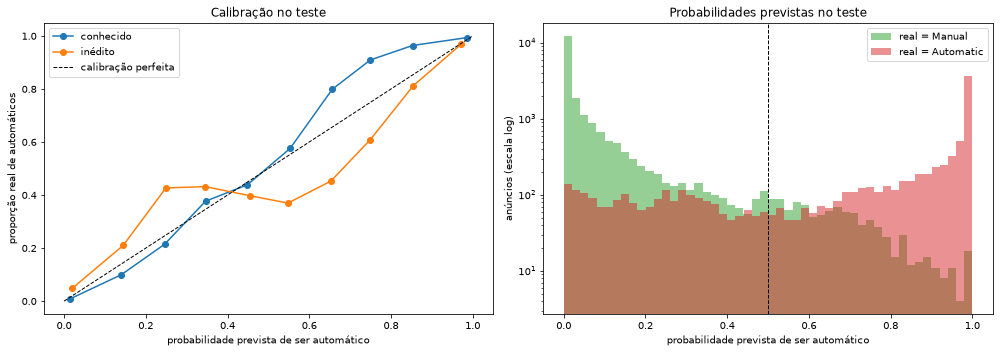

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Curva de calibração: pontos na diagonal = probabilidades confiáveis
for tipo, cor in [("conhecido", "tab:blue"), ("inédito", "tab:orange")]:
    d = erros_cambio[erros_cambio["tipo"] == tipo]
    cal = d.groupby("faixa_proba", observed=True).agg(prev=("proba", "mean"), real=("auto", "mean"))
    axes[0].plot(cal["prev"], cal["real"], "o-", color=cor, label=tipo)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="calibração perfeita")
axes[0].set_xlabel("probabilidade prevista de ser automático")
axes[0].set_ylabel("proporção real de automáticos")
axes[0].set_title("Calibração no teste")
axes[0].legend()

# 2) Distribuição das probabilidades, separada pela classe real
for real, cor in [("Manual", "tab:green"), ("Automatic", "tab:red")]:
    axes[1].hist(erros_cambio.loc[erros_cambio["real"] == real, "proba"], bins=50,
                 alpha=0.5, color=cor, label=f"real = {real}")
axes[1].axvline(0.5, color="k", linestyle="--", linewidth=1)
axes[1].set_yscale("log")
axes[1].set_xlabel("probabilidade prevista de ser automático")
axes[1].set_ylabel("anúncios (escala log)")
axes[1].set_title("Probabilidades previstas no teste")
axes[1].legend()

plt.tight_layout()
plt.show()

In [86]:
# onde codigo erra 
def tabela_erro_cambio(d, por, minimo=100):
    """Taxa de erro, % de automáticos real e probabilidade média prevista, por grupo."""
    t = (d.groupby(por, observed=True)
          .agg(anuncios=("errou", "size"),
               erro_pct=("errou", "mean"),
               automatico_real_pct=("auto", "mean"),
               proba_media_pct=("proba", "mean")))
    t[["erro_pct", "automatico_real_pct", "proba_media_pct"]] *= 100
    return t[t["anuncios"] >= minimo].sort_values("erro_pct", ascending=False).round(1)


print("Por combustível:")
print(tabela_erro_cambio(erros_cambio, "fuel"), "\n")
print("Por carroceria:")
print(tabela_erro_cambio(erros_cambio, "body"), "\n")
print("Por marca (300+ anúncios no teste) — as 10 com mais erro:")
print(tabela_erro_cambio(erros_cambio, "maker", minimo=300).head(10), "\n")

# "Zona de dúvida": quanto o modelo acerta quando está confiante × quando está em dúvida
erros_cambio["confianca"] = np.where(erros_cambio["proba"].between(0.2, 0.8),
                                     "em dúvida (20–80%)", "confiante (<20% ou >80%)")
print("Confiança do modelo:")
print(erros_cambio.groupby("confianca").agg(
    anuncios=("errou", "size"), pct_dos_anuncios=("errou", lambda s: len(s) / len(erros_cambio) * 100),
    acerto_pct=("errou", lambda s: (1 - s.mean()) * 100)).round(1))

Por combustível:
                anuncios  erro_pct  automatico_real_pct  proba_media_pct
fuel                                                                    
Petrol             15170      11.9                 24.2             23.7
Diesel             14723       8.8                 32.2             30.1
Hybrid Petrol        467       0.2                 97.2             97.4
Plug-in Hybrid       111       0.0                100.0             99.9 

Por carroceria:
             anuncios  erro_pct  automatico_real_pct  proba_media_pct
body                                                                 
Van               207      18.4                 37.2             34.4
Coupe            2992      15.0                 43.6             38.4
Pickup            252      13.5                 37.3             38.2
SUV              6831      12.9                 36.7             38.6
Estate           2470      11.4                 39.1             37.0
Convertible      1153      10.3      

In [87]:
# erro + confiante
# Erros em que o modelo estava muito seguro (>95% ou <5%)
erros_cambio["certeza"] = (erros_cambio["proba"] - 0.5).abs() * 2   # 0 = dúvida total, 1 = certeza total
(erros_cambio[erros_cambio["errou"]]
    .sort_values("certeza", ascending=False)
    .head(10)[["maker", "tipo", "fuel", "body", "first_reg", "power_bhp", "disp", "real", "proba"]]
    .round(3))

,maker,tipo,fuel,body,first_reg,power_bhp,disp,real,proba
76783,Nissan,conhecido,Petrol,MPV,2016.0,NaN,3.5,Manual,1.000
90665,Renault,inédito,Petrol,Hatchback,2002.0,75.0,1.2,Automatic,0.000
83774,Aston Martin,inédito,Petrol,Coupe,2009.0,510.0,6.0,Manual,1.000
83769,Aston Martin,inédito,Petrol,Coupe,2009.0,510.0,6.0,Manual,1.000
83771,Aston Martin,inédito,Petrol,Coupe,2009.0,510.0,6.0,Manual,1.000
83767,Aston Martin,inédito,Petrol,Coupe,2009.0,510.0,6.0,Manual,0.999
90690,Renault,inédito,Petrol,Hatchback,2016.0,220.0,1.6,Automatic,0.001
83761,Aston Martin,inédito,Petrol,Coupe,2009.0,510.0,6.0,Manual,0.999
8339,Fiat,inédito,Diesel,MPV,2012.0,75.0,1.3,Automatic,0.001
90495,Renault,inédito,Petrol,Hatchback,2016.0,220.0,1.6,Automatic,0.001


**Resultado da análise de erros:**

**O erro mais grave: metade dos automáticos inéditos vira "Manual".** Nos carros conhecidos, o modelo reconhece 94% dos automáticos. Nos inéditos, só **50%**: quando não conhece o modelo de carro, ele "aposta" no câmbio mais comum do perfil (marca, motor, carroceria), que costuma ser manual. Os manuais quase nunca são confundidos (93–98% de acerto).

**Calibração:** nas faixas extremas (abaixo de 10% e acima de 80%), a probabilidade prevista bate com a proporção real (por exemplo, 98% previsto × 99% real). Na faixa do meio ela é menos precisa: entre 50% e 70% previstos, só 42–57% são automáticos de fato.

**Confiança:** **83% dos anúncios** recebem probabilidade abaixo de 20% ou acima de 80%, e nesses o acerto é de **96%**. Nos outros 17% (20–80%), o acerto cai para 60%.

**Onde erra mais:**
- **Combustível:** híbridos e plug-in são acertados em ~100%; toda a dificuldade está em gasolina (12% de erro) e diesel (9%).
- **Carroceria:** vans (18%), cupês (15%) e SUVs (13%) são as mais difíceis; hatches, as mais fáceis (7%).
- **Marca:** Nissan (23%), Audi (17%), Saab (17%) e Volkswagen (15%) lideram os erros. Na Nissan, o modelo superestima os automáticos (probabilidade média de 21% contra 15% reais).

**Os erros mais confiantes** são quase todos de carros inéditos que fogem do próprio perfil: Aston Martin de 510 cv **manuais** (o modelo diz ~100% automático), Renault hatch de 220 cv **automáticos** (o modelo diz ~0%) e uma Fiat MPV automática. O modelo não tinha como saber, porque nunca viu esses modelos de carro.

**Consequência prática para o formulário:** com probabilidade abaixo de 20% ou acima de 80%, o câmbio pode ser **preenchido automaticamente** (96% de acerto). Entre esses valores, o mais seguro é **sugerir e pedir para o vendedor confirmar**.

#### A função de previsão do Modelo 2

`prever_cambio()` recebe a base passada por `preparar()` e devolve a probabilidade e a classe; não precisa de `EstatisticasRef` nem de versão reserva.

In [88]:
def prever_cambio(d_preparado):
    """Recebe a base já passada por preparar() e devolve a probabilidade e a classe prevista."""
    proba = modelo_cambio.predict_proba(d_preparado[FEATURES_CAMBIO])[:, 1]
    return pd.DataFrame({"pred": np.where(proba >= 0.5, "Automatic", "Manual"),
                         "proba": proba}, index=d_preparado.index)


# Teste rápido: roda no arquivo de avaliação simulado (sem price e sem gearbox)
p = prever_cambio(preparar(avaliacao_fake))
print("previsões:", len(p), "| sem NaN:", not p["proba"].isna().any())
print(p["pred"].value_counts().to_dict())

previsões: 300 | sem NaN: True
{'Manual': 185, 'Automatic': 115}


#### Resumo do Modelo 2 — Câmbio

**Modelo final:** combinação de **0,7 × HistGradientBoostingClassifier (max_leaf_nodes = 127)** com **0,3 × rede neural (MLPClassifier 32-16)**: média ponderada das duas probabilidades, treinada em treino + validação. Saídas: `pred` (`Automatic`/`Manual`, corte em 50%) e `proba` (probabilidade de `Automatic`).

**Pontuações de todos os modelos testados (validação, log loss média de conhecido e inédito):**

| Modelo | Melhor config | Log loss médio | Acurácia conhecido | Acurácia inédito |
|---|---|---|---|---|
| **Combinação (0,7 boosting + 0,3 rede)** | — | **0,174** | 96,1% | 91,3% |
| HistGradientBoosting | 127 folhas | 0,180 | 96,1% | 90,7% |
| Random Forest | max_depth = 20 | 0,228 | 96,0% | 87,7% |
| Rede neural (MLP) | 32-16 | 0,267 | 91,6% | 91,0% |
| Logística L2 | C = 10 | 0,345 | 84,2% | 88,1% |
| Logística L1 | C = 0,01 | 0,373 | 83,8% | 87,4% |
| Decision Tree | max_depth = 8 | 0,412 | 85,5% | 83,5% |
| Baseline | — | 0,655 | 61,9% | 65,9% |

**Cenário temporal (treino até 2020, anúncios de 2021, com 55% de automáticos):** combinação 0,374 (84,4%), boosting 0,375, logística 0,398, rede neural 0,505.

**Desempenho final (teste):** **96,4% de acurácia** em modelos de carro conhecidos (log loss 0,108, AUC 0,993) e **83,6%** em modelos inéditos (log loss 0,356, AUC 0,880).

**Principais decisões:** log loss como métrica principal; mesmos grupos do Modelo 1, escolha pela média de conhecido e inédito; preço fora (ganho pequeno e dependência circular); combinação boosting + rede (melhor nas duas divisões testadas); logística usada para interpretar os pesos.

**Escopo de validade (onde confiar no modelo):**
- ✅ **Confiável:** carros de modelos já presentes na base (~96% de acurácia); híbridos e elétricos (~100%); e, em qualquer carro, previsões abaixo de 20% ou acima de 80% (83% dos anúncios, 96% de acerto).
- ⚠️ **Menos confiável:** modelos de carro inéditos (84–91% de acurácia, dependendo de quais modelos); anúncios de outro período (84% em 2021); vans, cupês e SUVs; marcas como Nissan, Audi, Saab e Volkswagen.
- ❌ **Não confiável:** **automáticos de modelos inéditos** (só metade é reconhecida); previsões entre 20% e 80% (60% de acerto), em que o formulário deve pedir confirmação; versões "fora do perfil" (esportivo potente manual, hatch potente automático).

**Limitações:**
- Na dúvida, o modelo vai para "Manual", a classe mais comum: é a origem do erro nos automáticos inéditos;
- O resultado em carros inéditos depende muito de quais modelos caem no conjunto, e o tamanho do boosting (15 a 127 folhas) muda de uma divisão para outra sem diferença relevante;
- Este teste já tinha sido usado uma vez para o boosting sozinho (ver *Modelo final e avaliação no teste*); no teste, o ganho da combinação foi menor que na validação;
- A base não tem a versão exata do carro (só o modelo, `ref_code`), então o modelo não distingue versões de um mesmo modelo que diferem só no câmbio.

## FINAL — PREDICTION SECTION

Aplica `preparar()`, `prever_preco()` (versão principal ou reserva) e `prever_cambio()` ao arquivo de avaliação e grava os dois CSVs. Todo anúncio recebe previsão.

**Para usar:** ajuste `ARQUIVO_AVALIACAO`. Sem o arquivo, a célula roda só uma demonstração e grava `demo_predicoes_...csv`.

In [89]:
import os

ARQUIVO_AVALIACAO = "cars_avaliacao.csv"   # <- trocar pelo nome do arquivo de avaliação

if os.path.exists(ARQUIVO_AVALIACAO):
    novos = pd.read_csv(ARQUIVO_AVALIACAO, low_memory=False)
    prefixo = ""
else:
    # Sem o arquivo de avaliação, rodamos só uma DEMONSTRAÇÃO com o arquivo simulado. Os CSVs ganham o
    # prefixo "demo_", para nunca serem confundidos com as previsões de verdade.
    print(f"ATENÇÃO: '{ARQUIVO_AVALIACAO}' não encontrado. Isto é só uma DEMONSTRAÇÃO com o arquivo simulado;"
          " os arquivos gravados começam com 'demo_'.")
    novos = avaliacao_fake.copy()
    prefixo = "demo_"
assert "id" in novos.columns, "o arquivo de avaliação precisa da coluna id"

novos_prep = preparar(novos)

# Modelo 1 — preço
saida_preco = pd.DataFrame({"id": novos_prep["id"].to_numpy(), "pred": prever_preco(novos_prep)})

# Modelo 2 — câmbio
cambio = prever_cambio(novos_prep)
saida_cambio = pd.DataFrame({"id": novos_prep["id"].to_numpy(),
                             "pred": cambio["pred"].to_numpy(),
                             "proba": cambio["proba"].to_numpy()})

# Travas: uma previsão por anúncio, nenhuma vazia
assert len(saida_preco) == len(saida_cambio) == len(novos)
assert not saida_preco["pred"].isna().any() and not saida_cambio["proba"].isna().any()

arq_preco, arq_cambio = f"{prefixo}predicoes_modelo1_preco.csv", f"{prefixo}predicoes_modelo2_cambio.csv"
saida_preco.to_csv(arq_preco, index=False)
saida_cambio.to_csv(arq_cambio, index=False)

print("anúncios:", len(novos))
print("anúncios sem câmbio informado (usaram a versão reserva do Modelo 1):", int(novos_prep["auto"].isna().sum()))
print("arquivos gravados:", arq_preco, "e", arq_cambio)
display(saida_preco.head())
display(saida_cambio.head())

ATENÇÃO: 'cars_avaliacao.csv' não encontrado. Isto é só uma DEMONSTRAÇÃO com o arquivo simulado; os arquivos gravados começam com 'demo_'.
anúncios: 300
anúncios sem câmbio informado (usaram a versão reserva do Modelo 1): 300
arquivos gravados: demo_predicoes_modelo1_preco.csv e demo_predicoes_modelo2_cambio.csv


,id,pred
0,A7526842,3632.414389
1,A5288848,2698.762387
2,A9352322,5673.138165
3,A4354501,32723.074366
4,A1068236,6459.211117


,id,pred,proba
0,A7526842,Manual,0.068716
1,A5288848,Automatic,0.997914
2,A9352322,Automatic,0.706748
3,A4354501,Automatic,0.999999
4,A1068236,Manual,0.002026
